Using sheet: 'Probe Frequency Domain'
Available columns before renaming: ['Probe', 'Time', 'Frequency (Hz)', 'Voltage Magnitude |V(t)|(V)', 'Current Magnitude |I(t)|(A)', 'Voltage Phase ∠V (degree)', 'Current Phase ∠I (degree)', 'Impedance Magnitude |Z(f)|(Ω)', 'Phase Difference (degree)', 'Real Impedance Re{z}(Ω)', 'Negative Imaginary Impedance -Im{z}(Ω)']
Available columns after renaming: ['Probe', 'time', 'frequency', 'Voltage Magnitude |V(t)|(V)', 'Current Magnitude |I(t)|(A)', 'Voltage Phase ∠V (degree)', 'Current Phase ∠I (degree)', 'Impedance Magnitude |Z(f)|(Ω)', 'Phase Difference (degree)', 'Z_real', 'Z_imag_neg']


Feature Extraction: 100%|██████████████████████████████████████████████████████████████| 75/75 [00:06<00:00, 12.08it/s]


TSFRESH features saved to 'ecm_features.xlsx'.
Saved ECM fitting results to 'ECM_fitting_results_advanced.xlsx'
       model_name                                             params  \
0  Advanced_2RCPE  [5e-324, 0.03761107914520926, 0.07902309698904...   
1  Advanced_2RCPE  [7.045384613262934e-09, 0.04027785016605508, 0...   
2  Advanced_2RCPE  [6.0967988626392084e-09, 0.032068462567683656,...   
3  Advanced_2RCPE  [7.057724824939383e-09, 0.04573823685960637, 0...   
4  Advanced_2RCPE  [7.210451107219214e-09, 0.04551139213412436, 0...   

                                         param_names      rmse          aic  \
0  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.003102 -1449.332705   
1  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.000943 -1735.138415   
2  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.002043 -1549.565608   
3  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.000925 -1739.762860   
4  [L0, R0, R1, L1, R2, CPE1-Q, CPE1-alpha, R3, C...  0.0009

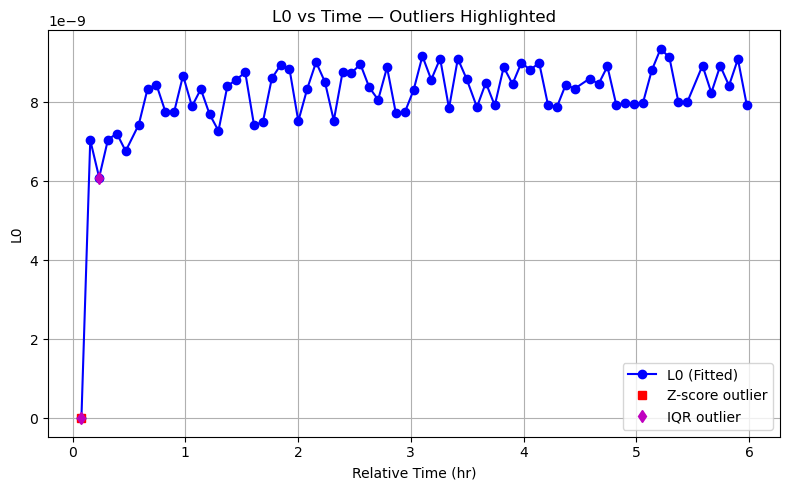

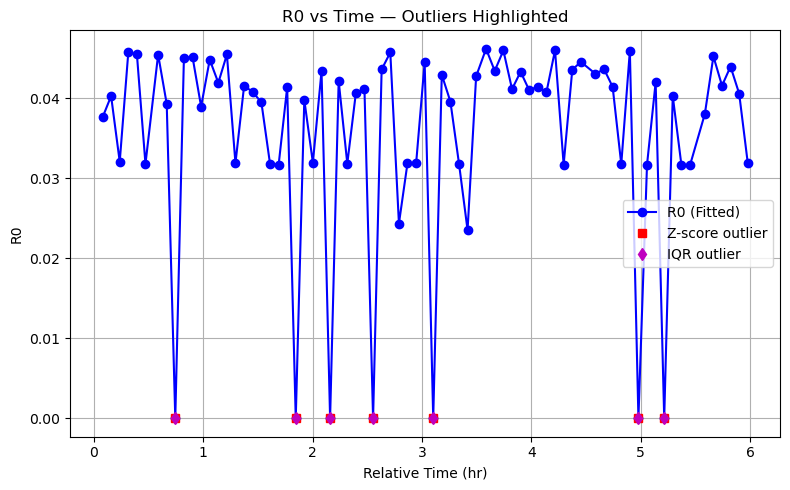

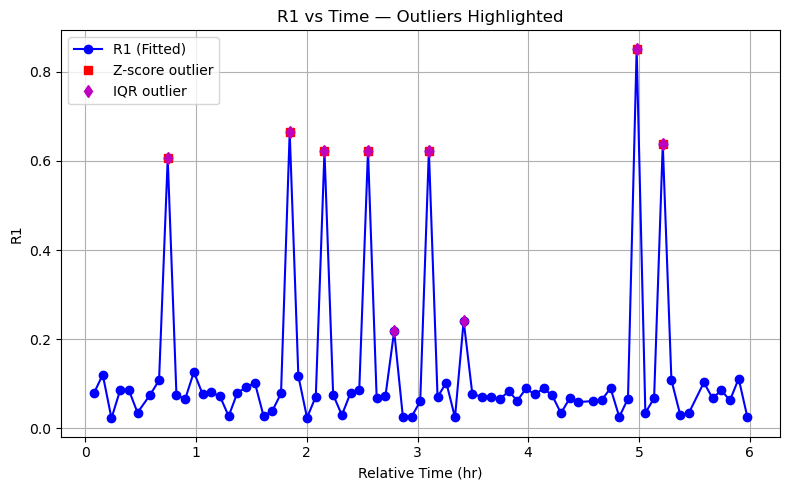

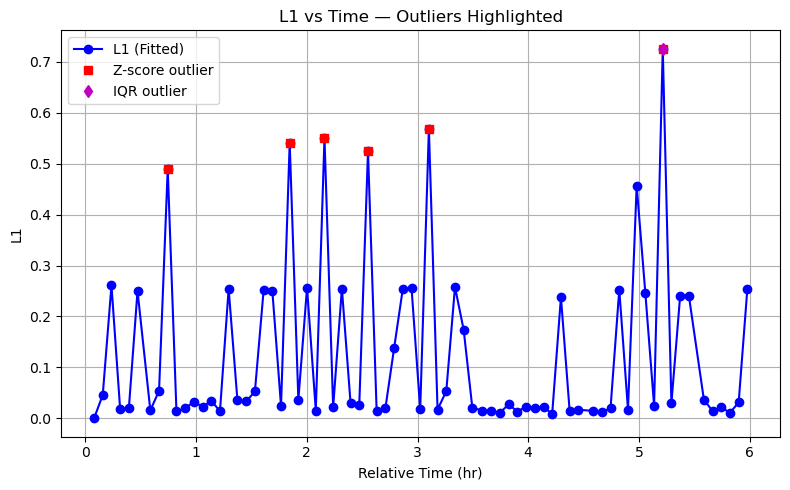

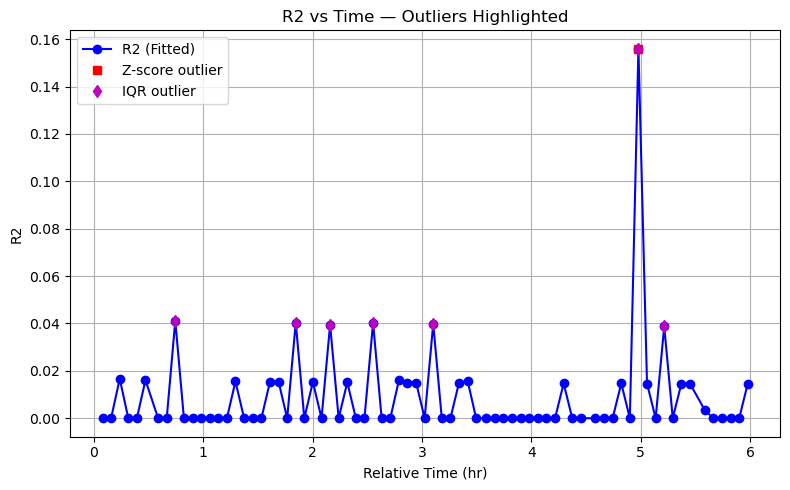

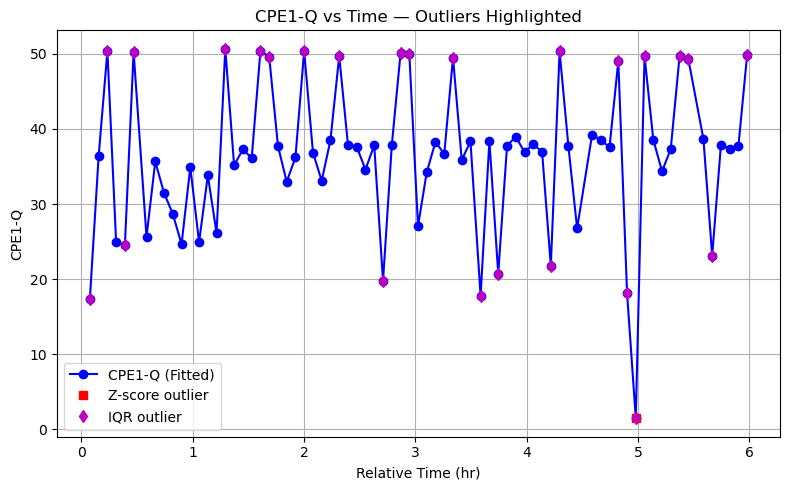

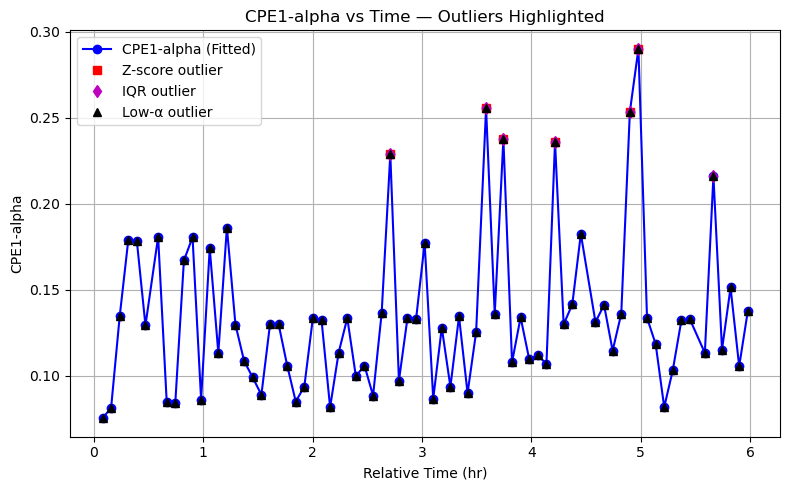

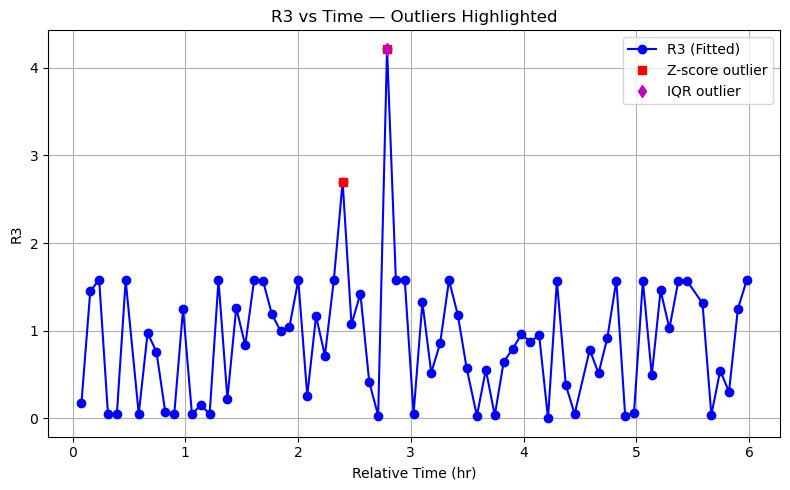

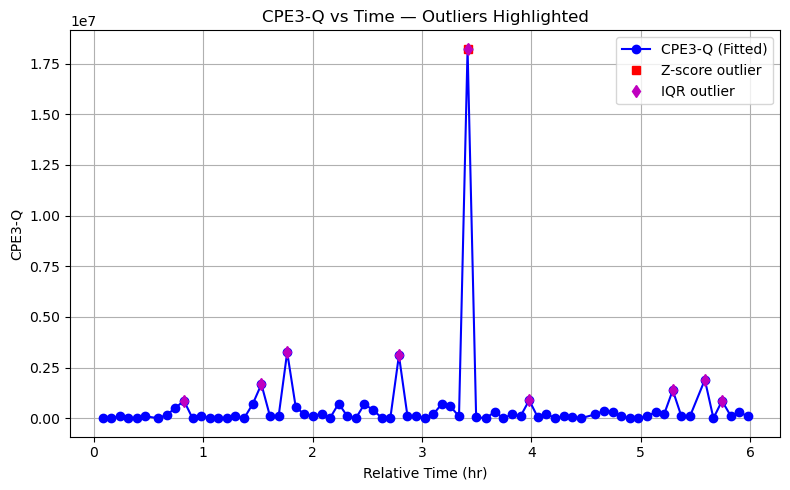

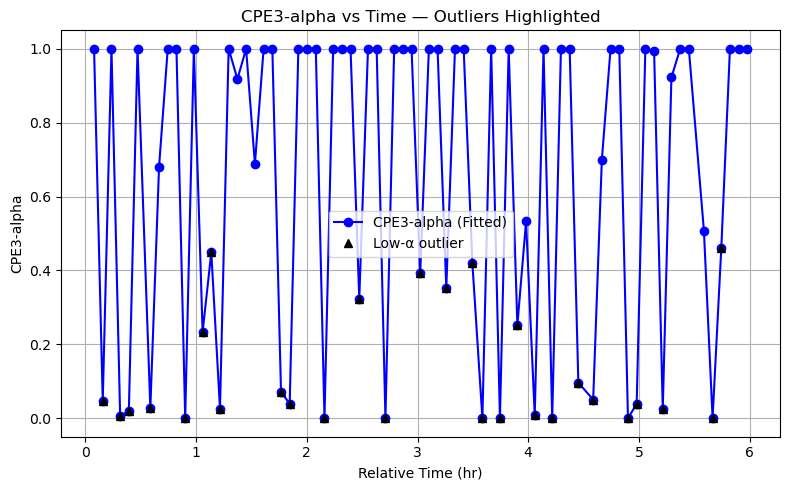

Number of non-outlier points: 73


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from datetime import datetime
from pathlib import Path
from impedance.models.circuits import CustomCircuit
from impedance import preprocessing
from tsfresh import extract_features
from tsfresh.utilities.dataframe_functions import impute

warnings.filterwarnings("ignore")

# 1. DATA LOADING: MULTI-SHEET EXCEL (6300.xls)
file_path = "6300.xls"  # Ensure this path points to your Excel file
all_sheets = pd.read_excel(file_path, sheet_name=None)

# Select the appropriate sheet
if "Probe Frequency Domain" in all_sheets and not all_sheets["Probe Frequency Domain"].empty:
    df_eis = all_sheets["Probe Frequency Domain"]
    print("Using sheet: 'Probe Frequency Domain'")
elif "EIS_Data" in all_sheets and not all_sheets["EIS_Data"].empty:
    df_eis = all_sheets["EIS_Data"]
    print("Using sheet: 'EIS_Data'")
else:
    for sheet_name, sheet_df in all_sheets.items():
        if not sheet_df.empty:
            df_eis = sheet_df
            print(f"Using sheet: '{sheet_name}' (fallback)")
            break
    else:
        raise ValueError("No nonempty sheet found in 6300.xls.")

# 2. DATA CLEANUP & TIME DERIVATION
print("Available columns before renaming:", df_eis.columns.tolist())
rename_map = {
    "Frequency (Hz)": "frequency",
    "Real Impedance Re{z}(Ω)": "Z_real",
    "Negative Imaginary Impedance -Im{z}(Ω)": "Z_imag_neg",
    "Time": "time"
}
df_eis.rename(columns=rename_map, inplace=True)
print("Available columns after renaming:", df_eis.columns.tolist())

required_cols = ["frequency", "Z_real", "Z_imag_neg"]
missing = [col for col in required_cols if col not in df_eis.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}.")
df_eis.dropna(subset=required_cols, inplace=True)

if "time" in df_eis.columns:
    df_eis["time"] = pd.to_datetime(df_eis["time"], errors="coerce")
    df_eis.dropna(subset=["time"], inplace=True)
    df_eis["RelTime_sec"] = (df_eis["time"] - df_eis["time"].min()).dt.total_seconds()
    df_eis["RelTime_hr"] = df_eis["RelTime_sec"] / 3600
else:
    df_eis["RelTime_hr"] = np.arange(len(df_eis)) * 0.1  # Fallback time assignment

df_eis["sweep_id"] = df_eis.groupby("time").ngroup() if "time" in df_eis.columns else np.arange(len(df_eis))

# 3. AUTO-FEATURIZATION WITH TSFRESH (OPTIONAL)
df_tsfresh = df_eis[["sweep_id", "frequency", "Z_real"]].rename(
    columns={"sweep_id": "id", "frequency": "time", "Z_real": "value"}
)
extracted_features = extract_features(df_tsfresh, column_id="id", column_sort="time", n_jobs=0)
extracted_features = impute(extracted_features)
extracted_features.reset_index(inplace=True)
extracted_features.rename(columns={"index": "sweep_id"}, inplace=True)
extracted_features.to_excel("ecm_features.xlsx", index=False)
print("TSFRESH features saved to 'ecm_features.xlsx'.")

# 4. DEFINE ECM MODEL
advanced_model_info = {
    "name": "Advanced_2RCPE",
    "circuit": "L0-R0-p(R1-L1, R2-CPE1, R3-CPE3)",
    "initial_guess": [
        0.0,       # L0
        0.04941,   # R0
        0.0083883, # R1
        2.0785,    # L1
        0.0083683, # R2
        0.46421,   # CPE1-Q
        1.0,       # CPE1-alpha
        2.2071,    # R3
        1.0,       # CPE3-Q
        1.0        # CPE3-alpha
    ],
    "param_names": ["L0", "R0", "R1", "L1", "R2", "CPE1-Q", "CPE1-alpha", "R3", "CPE3-Q", "CPE3-alpha"]
}
model_candidates = [advanced_model_info]

# 5. ECM FITTING FUNCTION
def fit_and_evaluate_model(model_dict, freq, Z_exp):
    circuit_str = model_dict["circuit"]
    init_guess = model_dict["initial_guess"]
    circuit_model = CustomCircuit(circuit=circuit_str, initial_guess=init_guess)
    circuit_model.fit(freq, Z_exp)
    Z_fit = circuit_model.predict(freq)
    residuals = Z_exp - Z_fit
    rmse = np.sqrt(np.mean(np.abs(residuals)**2))
    n = len(freq)
    k = len(circuit_model.parameters_)
    rss = np.sum(np.abs(residuals)**2)
    N_eff = 2 * n
    aic = 2 * k + N_eff * np.log(rss / N_eff + 1e-15)
    bic = np.log(N_eff) * k + N_eff * np.log(rss / N_eff + 1e-15)
    param_names = model_dict["param_names"]
    fitted_params = circuit_model.parameters_
    # Check for negative R or L values
    for name, value in zip(param_names, fitted_params):
        if (name.startswith('R') or name.startswith('L')) and value < 0:
            return None
    return {
        "model_name": model_dict["name"],
        "params": fitted_params,
        "param_names": param_names,
        "rmse": rmse,
        "aic": aic,
        "bic": bic
    }

# Perform ECM fitting
fit_results = []
for sweep_id, group in df_eis.groupby("sweep_id"):
    group = group.sort_values("frequency")
    if len(group) < 3:
        continue
    freq = group["frequency"].values
    Z_exp = group["Z_real"].values + 1j * (-group["Z_imag_neg"].values)
    if not np.all(np.isfinite(Z_exp)) or np.any(freq <= 0):
        continue
    result = fit_and_evaluate_model(advanced_model_info, freq, Z_exp)
    if result is not None and (result["rmse"]/np.mean(np.abs(Z_exp))*100) <= 10.0:
        time_val = group["time"].iloc[0] if "time" in group.columns else None
        rel_time_hr = group["RelTime_hr"].iloc[0]
        result.update({"sweep_id": sweep_id, "time": time_val, "RelTime_hr": rel_time_hr})
        fit_results.append(result)

fit_df = pd.DataFrame(fit_results)
if fit_df.empty:
    raise RuntimeError("No valid ECM fits found.")
fit_df.to_excel("ECM_fitting_results_advanced.xlsx", index=False)
print("Saved ECM fitting results to 'ECM_fitting_results_advanced.xlsx'")
print(fit_df.head())

# 6. PLOT PARAMETERS AND DETECT OUTLIERS
param_names = advanced_model_info["param_names"]
for i, pname in enumerate(param_names):
    fit_df[pname] = fit_df["params"].apply(lambda x: x[i] if len(x) > i else np.nan)

# Ensure RelTime_hr is available
if "RelTime_hr" not in fit_df.columns:
    rel_time = df_eis.groupby("sweep_id")["RelTime_hr"].mean().reset_index()
    fit_df = pd.merge(fit_df, rel_time, on="sweep_id", how="left")

# Plot parameters with outlier detection
for pname in param_names:
    plt.figure(figsize=(8, 5))
    plt.plot(fit_df["RelTime_hr"], fit_df[pname], 'bo-', label=f'{pname} (Fitted)')
    # Z-score outliers
    z_scores = (fit_df[pname] - fit_df[pname].mean()) / fit_df[pname].std()
    z_out = fit_df[abs(z_scores) > 2]
    if not z_out.empty:
        plt.plot(z_out["RelTime_hr"], z_out[pname], 'rs', label='Z-score outlier')
    # IQR outliers
    Q1, Q3 = fit_df[pname].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    iqr_mask = (fit_df[pname] < Q1 - 1.5*IQR) | (fit_df[pname] > Q3 + 1.5*IQR)
    iqr_out = fit_df[iqr_mask]
    if not iqr_out.empty:
        plt.plot(iqr_out["RelTime_hr"], iqr_out[pname], 'md', label='IQR outlier')
    # Alpha-bound outliers
    if 'alpha' in pname.lower():
        bound_mask = fit_df[pname] < 0.5
        bound_out = fit_df[bound_mask]
        if not bound_out.empty:
            plt.plot(bound_out["RelTime_hr"], bound_out[pname], 'k^', label='Low-α outlier')
    plt.xlabel("Relative Time (hr)")
    plt.ylabel(pname)
    plt.title(f"{pname} vs Time — Outliers Highlighted")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 7. OUTLIER HANDLING
# Define moving average guess function
def moving_average_guess(fit_df, target_time, window=3):
    majority_df = fit_df[~fit_df['is_outlier']].copy()
    if majority_df.empty:
        print("Warning: No majority points to average from. Using median parameters as fallback.")
        # Use median parameters from all sweeps as a fallback
        param_matrix = np.stack(fit_df['params'].values)
        median_guess = np.median(param_matrix, axis=0)
        return median_guess.tolist()
    majority_df['time_diff'] = np.abs(majority_df['RelTime_hr'] - target_time)
    sorted_df = majority_df.sort_values('time_diff')
    neighbors = sorted_df.head(window)
    if neighbors.empty:
        print("Warning: No nearby majority sweeps found. Using median parameters.")
        param_matrix = np.stack(fit_df['params'].values)
        median_guess = np.median(param_matrix, axis=0)
        return median_guess.tolist()
    param_matrix = np.stack(neighbors['params'].values)
    avg_guess = param_matrix.mean(axis=0)
    return avg_guess.tolist()

# Identify outliers with a more balanced criterion
alpha_cols = [c for c in param_names if 'alpha' in c.lower()]
fit_df['is_alpha_outlier'] = fit_df[alpha_cols].min(axis=1) < 0.7  # Relaxed threshold
z = (fit_df['rmse'] - fit_df['rmse'].mean()) / fit_df['rmse'].std()
fit_df['is_rmse_outlier'] = abs(z) > 2
# Mark as outlier if both alpha is low AND RMSE is extreme
fit_df['is_outlier'] = fit_df['is_alpha_outlier'] & fit_df['is_rmse_outlier']

# Check if all points are outliers and adjust if necessary
if fit_df['is_outlier'].all():
    print("All points flagged as outliers by combined criterion. Using RMSE Z-score alone.")
    fit_df['is_outlier'] = abs(z) > 2

# Verify some non-outliers exist
non_outliers = fit_df[~fit_df['is_outlier']]
print(f"Number of non-outlier points: {len(non_outliers)}")

# Process outliers
outlier_results = []
for _, row in fit_df[fit_df['is_outlier']].iterrows():
    sweep = row['sweep_id']
    t = row['RelTime_hr']
    orig_params = row['params']
    orig_rmse = row['rmse']
    
    # Generate new initial guess
    new_guess = moving_average_guess(fit_df, t, window=3)
    
    # Re-fit with new guess
    grp = df_eis[df_eis['sweep_id'] == sweep].sort_values('frequency')
    freq = grp['frequency'].values
    Zexp = grp['Z_real'].values + 1j * (-grp['Z_imag_neg'].values)
    
    circ = CustomCircuit(circuit=advanced_model_info['circuit'], initial_guess=new_guess)
    circ.fit(freq, Zexp)
    Zfit_new = circ.predict(freq)
    rmse_new = np.sqrt(np.mean(np.abs(Zexp - Zfit_new)**2))
    
    # Validate new parameters
    params_valid = all(
        val >= 0 for name, val in zip(advanced_model_info['param_names'], circ.parameters_)
        if name.startswith('R') or name.startswith('L')
    )
    
    # Decide action
    if rmse_new < orig_rmse and params_valid:
        action = 'corrected'
        fit_df.loc[fit_df['sweep_id'] == sweep, ['params', 'rmse']] = [circ.parameters_, rmse_new]
        fit_df.loc[fit_df['sweep_id'] == sweep, 'is_outlier'] = False
    else:
        action = 'persisted'
        outlier_results.append({
            'sweep_id': sweep,
            'time': row['time'],
            'orig_rmse': orig_rmse,
            'new_rmse': rmse_new,
            **{f'orig_p_{n}': val for n, val in zip(advanced_model_info['param_names'], orig_params)},
            **{f'new_p_{n}': val for n, val in zip(advanced_model_info['param_names'], circ.parameters_)}
        })
    
    print(f"Sweep {sweep} ({action}): orig RMSE={orig_rmse:.2e}, new RMSE={rmse_new:.2e}")

# Save persistent outliers
if outlier_results:
    df_persist = pd.DataFrame(outlier_results)
    df_persist.to_excel("persistent_outliers.xlsx", index=False)
    print(f"Saved {len(df_persist)} persistent outliers to 'persistent_outliers.xlsx'")
else:
    print("All outliers were corrected by moving-average initial guesses.")

Using sheet: 'Probe Frequency Domain'
Available columns before renaming: ['Probe', 'Time', 'Frequency (Hz)', 'Voltage Magnitude |V(t)|(V)', 'Current Magnitude |I(t)|(A)', 'Voltage Phase ∠V (degree)', 'Current Phase ∠I (degree)', 'Impedance Magnitude |Z(f)|(Ω)', 'Phase Difference (degree)', 'Real Impedance Re{z}(Ω)', 'Negative Imaginary Impedance -Im{z}(Ω)']
Available columns after renaming: ['Probe', 'time', 'frequency', 'Voltage Magnitude |V(t)|(V)', 'Current Magnitude |I(t)|(A)', 'Voltage Phase ∠V (degree)', 'Current Phase ∠I (degree)', 'Impedance Magnitude |Z(f)|(Ω)', 'Phase Difference (degree)', 'Z_real', 'Z_imag_neg']


Feature Extraction: 100%|██████████████████████████████████████████████████████████████| 75/75 [00:07<00:00, 10.63it/s]


TSFRESH features saved to 'ecm_features.xlsx'.
Saved ECM fitting results to 'ECM_fitting_results_advanced.xlsx'


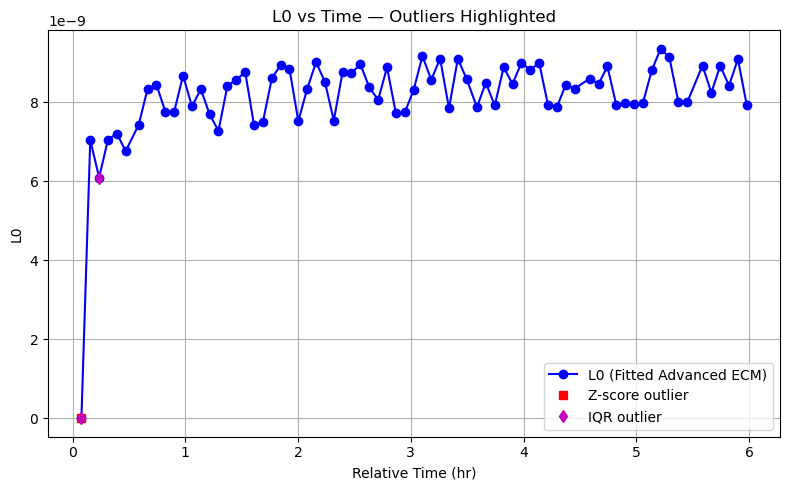

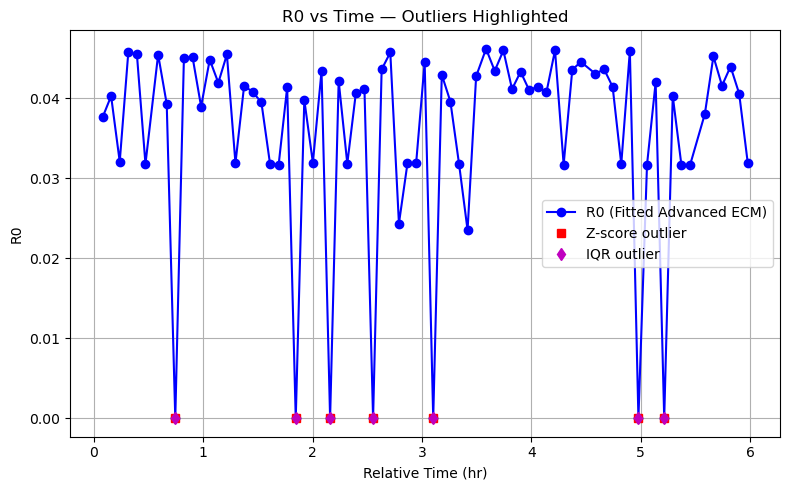

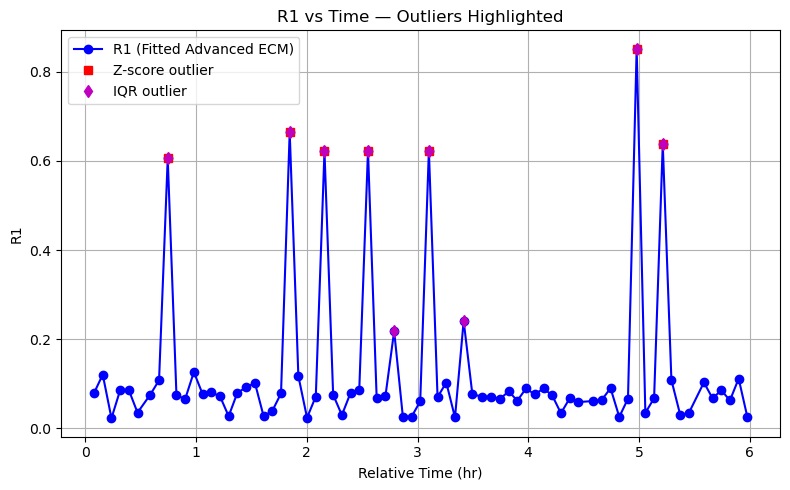

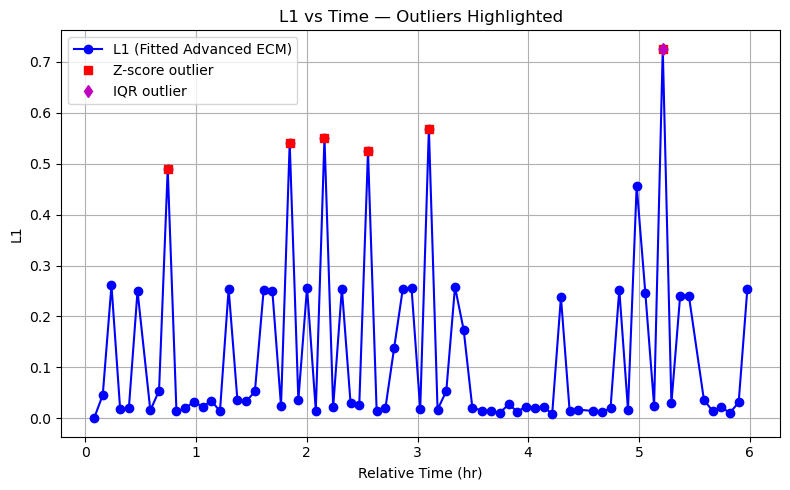

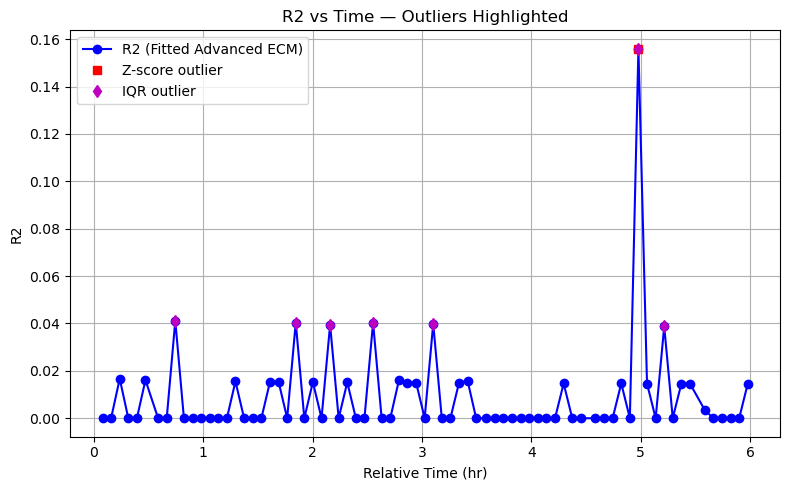

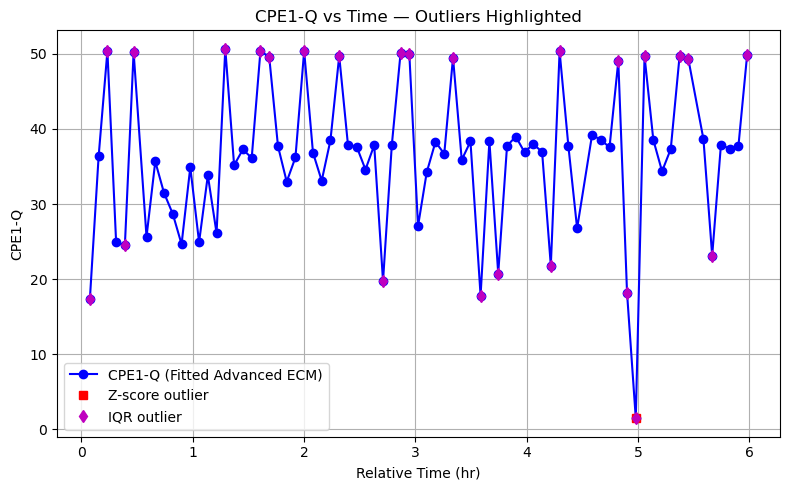

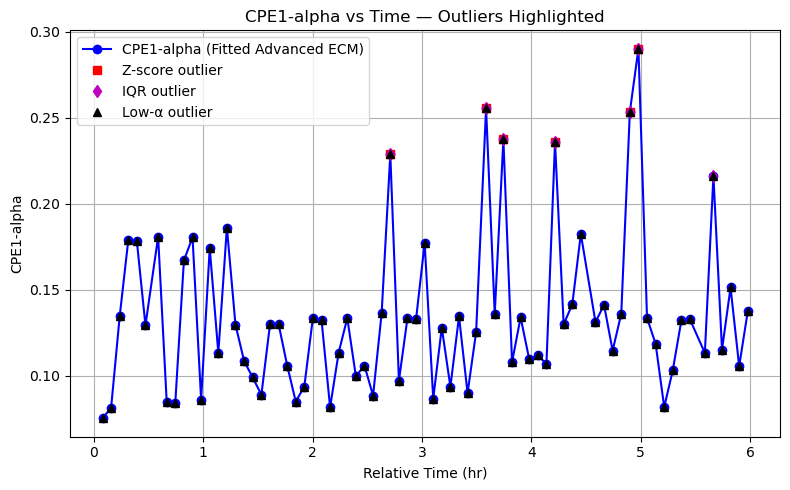

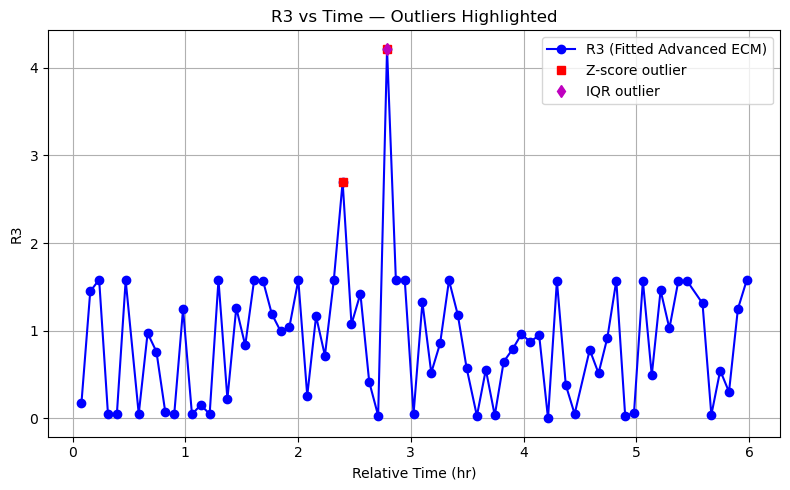

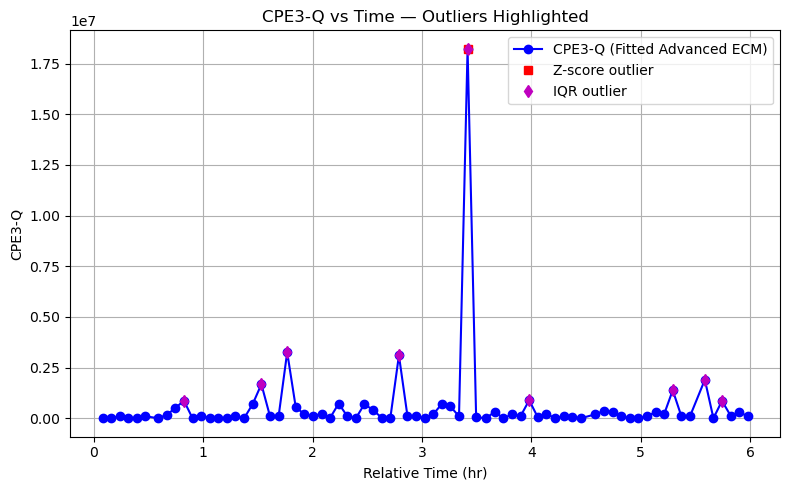

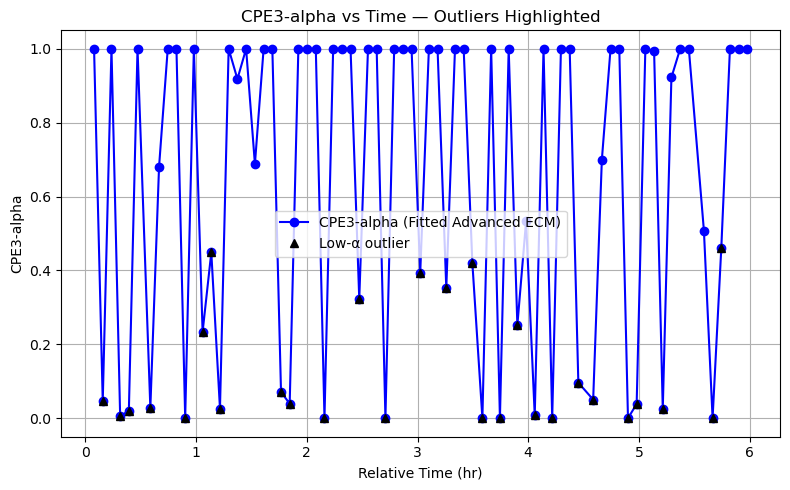

Sweep 1 (corrected): orig RMSE=3.10e-03, new RMSE=2.83e-03
All outliers were corrected by moving-average initial guesses.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from impedance.models.circuits import CustomCircuit
from impedance import preprocessing
from tsfresh import extract_features
from tsfresh.utilities.dataframe_functions import impute

warnings.filterwarnings("ignore")

# --- 1. Data Loading from Multi-Sheet Excel ---
file_path = "6300.xls"  # Update with your actual file path
all_sheets = pd.read_excel(file_path, sheet_name=None)

# Prefer "Probe Frequency Domain" sheet, with fallbacks
if "Probe Frequency Domain" in all_sheets and not all_sheets["Probe Frequency Domain"].empty:
    df_eis = all_sheets["Probe Frequency Domain"]
    print("Using sheet: 'Probe Frequency Domain'")
elif "EIS_Data" in all_sheets and not all_sheets["EIS_Data"].empty:
    df_eis = all_sheets["EIS_Data"]
    print("Using sheet: 'EIS_Data'")
else:
    for sheet_name, sheet_df in all_sheets.items():
        if not sheet_df.empty:
            df_eis = sheet_df
            print(f"Using sheet: '{sheet_name}' (fallback)")
            break
    else:
        raise ValueError("No nonempty sheet found in 6300.xls.")

# --- 2. Data Cleanup & Time Derivation ---
print("Available columns before renaming:", df_eis.columns.tolist())
rename_map = {
    "Frequency (Hz)": "frequency",
    "Real Impedance Re{z}(Ω)": "Z_real",
    "Negative Imaginary Impedance -Im{z}(Ω)": "Z_imag_neg",
    "Time": "time"
}
df_eis.rename(columns=rename_map, inplace=True)
print("Available columns after renaming:", df_eis.columns.tolist())

required_cols = ["frequency", "Z_real", "Z_imag_neg"]
missing = [col for col in required_cols if col not in df_eis.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}.")
df_eis.dropna(subset=required_cols, inplace=True)

if "time" in df_eis.columns:
    df_eis["time"] = pd.to_datetime(df_eis["time"], errors="coerce")
    df_eis.dropna(subset=["time"], inplace=True)
    df_eis["RelTime_sec"] = (df_eis["time"] - df_eis["time"].min()).dt.total_seconds()
    df_eis["RelTime_hr"] = df_eis["RelTime_sec"] / 3600
else:
    df_eis["RelTime_hr"] = np.arange(len(df_eis)) * 0.1  # Arbitrary time step if no time column

df_eis["sweep_id"] = df_eis.groupby("time").ngroup() if "time" in df_eis.columns else 0

# --- 3. Optional Auto-Featurization with tsfresh ---
df_tsfresh = df_eis[["sweep_id", "frequency", "Z_real"]].rename(
    columns={"sweep_id": "id", "frequency": "time", "Z_real": "value"}
)
extracted_features = extract_features(df_tsfresh, column_id="id", column_sort="time", n_jobs=0)
extracted_features = impute(extracted_features)
extracted_features.reset_index(inplace=True)
extracted_features.rename(columns={"index": "sweep_id"}, inplace=True)
extracted_features.to_excel("ecm_features.xlsx", index=False)
print("TSFRESH features saved to 'ecm_features.xlsx'.")

# --- 4. Define ECM Model ---
advanced_model_info = {
    "name": "Advanced_2RCPE",
    "circuit": "L0-R0-p(R1-L1, R2-CPE1, R3-CPE3)",
    "initial_guess": [
        0.0,       # L0
        0.04941,   # R0
        0.0083883, # R1
        2.0785,    # L1
        0.0083683, # R2
        0.46421,   # CPE1-Q
        1.0,       # CPE1-alpha
        2.2071,    # R3
        1.0,       # CPE3-Q
        1.0        # CPE3-alpha
    ],
    "param_names": ["L0", "R0", "R1", "L1", "R2", "CPE1-Q", "CPE1-alpha", "R3", "CPE3-Q", "CPE3-alpha"]
}
model_candidates = [advanced_model_info]

# --- 5. ECM Fitting Function ---
def fit_and_evaluate_model(model_dict, freq, Z_exp):
    circuit_str = model_dict["circuit"]
    init_guess = model_dict["initial_guess"]
    circuit_model = CustomCircuit(circuit=circuit_str, initial_guess=init_guess)
    circuit_model.fit(freq, Z_exp)
    Z_fit = circuit_model.predict(freq)
    residuals = Z_exp - Z_fit
    rmse = np.sqrt(np.mean(np.abs(residuals)**2))
    n = len(freq)
    k = len(circuit_model.parameters_)
    rss = np.sum(np.abs(residuals)**2)
    N_eff = 2 * n
    aic = 2 * k + N_eff * np.log(rss / N_eff + 1e-15)
    bic = np.log(N_eff) * k + N_eff * np.log(rss / N_eff + 1e-15)
    param_names = model_dict["param_names"]
    fitted_params = circuit_model.parameters_
    # Validate physical parameters (resistances and inductances non-negative)
    for name, value in zip(param_names, fitted_params):
        if (name.startswith('R') or name.startswith('L')) and value < 0:
            return None
    return {
        "model_name": model_dict["name"],
        "params": fitted_params,
        "param_names": param_names,
        "rmse": rmse,
        "aic": aic,
        "bic": bic
    }

# Fit the model for each sweep
fit_results = []
for sweep_id, group in df_eis.groupby("sweep_id"):
    group = group.sort_values("frequency")
    if len(group) < 3:  # Minimum points for meaningful fit
        continue
    freq = group["frequency"].values
    Z_exp = group["Z_real"].values + 1j * (-group["Z_imag_neg"].values)
    if not np.all(np.isfinite(Z_exp)) or np.any(freq <= 0):
        continue
    result = fit_and_evaluate_model(advanced_model_info, freq, Z_exp)
    if result is not None and (result["rmse"]/np.mean(np.abs(Z_exp))*100) <= 10.0:  # 10% relative error threshold
        time_val = group["time"].iloc[0] if "time" in group.columns else None
        rel_time_hr = group["RelTime_hr"].iloc[0] if "RelTime_hr" in group.columns else None
        result.update({"sweep_id": sweep_id, "time": time_val, "RelTime_hr": rel_time_hr})
        fit_results.append(result)

fit_df = pd.DataFrame(fit_results)
if fit_df.empty:
    raise RuntimeError("No valid advanced model ECM fits found.")
fit_df.to_excel("ECM_fitting_results_advanced.xlsx", index=False)
print("Saved ECM fitting results to 'ECM_fitting_results_advanced.xlsx'")

# --- 6. Plot Parameters and Detect Outliers ---
param_names = advanced_model_info["param_names"]
for i, pname in enumerate(param_names):
    fit_df[pname] = fit_df["params"].apply(lambda x: x[i] if len(x) > i else np.nan)

# Ensure relative time is present
if "RelTime_hr" not in fit_df.columns:
    rel_time = df_eis.groupby("sweep_id")["RelTime_hr"].mean().reset_index()
    fit_df = pd.merge(fit_df, rel_time, on="sweep_id", how="left")

# Plot each parameter vs. time with outlier highlights
for pname in param_names:
    plt.figure(figsize=(8, 5))
    plt.plot(fit_df["RelTime_hr"], fit_df[pname], 'bo-', label=f'{pname} (Fitted Advanced ECM)')
    # Z-score outliers
    z_scores = (fit_df[pname] - fit_df[pname].mean()) / fit_df[pname].std()
    z_out = fit_df[abs(z_scores) > 2]
    if not z_out.empty:
        plt.plot(z_out["RelTime_hr"], z_out[pname], 'rs', label='Z-score outlier')
    # IQR outliers
    Q1, Q3 = fit_df[pname].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    iqr_mask = (fit_df[pname] < Q1 - 1.5*IQR) | (fit_df[pname] > Q3 + 1.5*IQR)
    iqr_out = fit_df[iqr_mask]
    if not iqr_out.empty:
        plt.plot(iqr_out["RelTime_hr"], iqr_out[pname], 'md', label='IQR outlier')
    # Alpha-specific bound
    if 'alpha' in pname.lower():
        bound_mask = fit_df[pname] < 0.5
        bound_out = fit_df[bound_mask]
        if not bound_out.empty:
            plt.plot(bound_out["RelTime_hr"], bound_out[pname], 'k^', label='Low-α outlier')
    plt.xlabel("Relative Time (hr)")
    plt.ylabel(pname)
    plt.title(f"{pname} vs Time — Outliers Highlighted")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- 7. Outlier Handling ---
# Function to compute moving average guess from non-outliers
def moving_average_guess(fit_df, target_time, window=3):
    majority_df = fit_df[~fit_df['is_outlier']].copy()
    if majority_df.empty:
        print("Warning: No majority points to average from. Using median parameters as fallback.")
        param_matrix = np.stack(fit_df['params'].values)
        median_guess = np.median(param_matrix, axis=0)
        return median_guess.tolist()
    majority_df['time_diff'] = np.abs(majority_df['RelTime_hr'] - target_time)
    sorted_df = majority_df.sort_values('time_diff')
    neighbors = sorted_df.head(window)
    if neighbors.empty:
        print("Warning: No nearby majority sweeps found. Using median parameters.")
        param_matrix = np.stack(fit_df['params'].values)
        median_guess = np.median(param_matrix, axis=0)
        return median_guess.tolist()
    param_matrix = np.stack(neighbors['params'].values)
    avg_guess = param_matrix.mean(axis=0)
    return avg_guess.tolist()

# Identify outliers using combined criterion
alpha_cols = [c for c in param_names if 'alpha' in c.lower()]
fit_df['is_alpha_outlier'] = fit_df[alpha_cols].min(axis=1) < 0.7  # Relaxed alpha threshold
z = (fit_df['rmse'] - fit_df['rmse'].mean()) / fit_df['rmse'].std()
fit_df['is_rmse_outlier'] = abs(z) > 2
fit_df['is_outlier'] = fit_df['is_alpha_outlier'] & fit_df['is_rmse_outlier']

# Fallback if all points are outliers
if fit_df['is_outlier'].all():
    print("All points flagged as outliers by combined criterion. Using RMSE Z-score alone.")
    fit_df['is_outlier'] = abs(z) > 2

# Process and correct outliers
outlier_results = []
for _, row in fit_df[fit_df['is_outlier']].iterrows():
    sweep = row['sweep_id']
    t = row['RelTime_hr']
    orig_params = row['params']
    orig_rmse = row['rmse']
    
    # New initial guess from moving average
    new_guess = moving_average_guess(fit_df, t, window=3)
    
    # Re-fit with new guess
    grp = df_eis[df_eis['sweep_id'] == sweep].sort_values('frequency')
    freq = grp['frequency'].values
    Zexp = grp['Z_real'].values + 1j * (-grp['Z_imag_neg'].values)
    
    circ = CustomCircuit(circuit=advanced_model_info['circuit'], initial_guess=new_guess)
    circ.fit(freq, Zexp)
    Zfit_new = circ.predict(freq)
    rmse_new = np.sqrt(np.mean(np.abs(Zexp - Zfit_new)**2))
    
    # Validate new parameters
    params_valid = all(
        val >= 0 for name, val in zip(advanced_model_info['param_names'], circ.parameters_)
        if name.startswith('R') or name.startswith('L')
    )
    
    # Update if improved and valid
    if rmse_new < orig_rmse and params_valid:
        action = 'corrected'
        idx = fit_df[fit_df['sweep_id'] == sweep].index[0]
        fit_df.at[idx, 'params'] = circ.parameters_
        fit_df.at[idx, 'rmse'] = rmse_new
        fit_df.at[idx, 'is_outlier'] = False
    else:
        action = 'persisted'
        outlier_results.append({
            'sweep_id': sweep,
            'time': row['time'],
            'orig_rmse': orig_rmse,
            'new_rmse': rmse_new,
            **{f'orig_p_{n}': val for n, val in zip(advanced_model_info['param_names'], orig_params)},
            **{f'new_p_{n}': val for n, val in zip(advanced_model_info['param_names'], circ.parameters_)}
        })
    
    print(f"Sweep {sweep} ({action}): orig RMSE={orig_rmse:.2e}, new RMSE={rmse_new:.2e}")

# Save persistent outliers
if outlier_results:
    df_persist = pd.DataFrame(outlier_results)
    df_persist.to_excel("persistent_outliers.xlsx", index=False)
    print(f"Saved {len(df_persist)} persistent outliers to 'persistent_outliers.xlsx'")
else:
    print("All outliers were corrected by moving-average initial guesses.")

In [19]:
# Original: alpha < 0.5 → outlier
fit_df['is_alpha_outlier'] = fit_df[alpha_cols].min(axis=1) < 0.5

# Modified: Allow lower alpha thresholds (e.g., 0.4)
fit_df['is_alpha_outlier'] = fit_df[alpha_cols].min(axis=1) < 0.4  # Adjust as needed

# If using RMSE Z-score, increase the threshold (e.g., Z > 3)
z_threshold = 3  # Instead of 2
alpha_mask = abs(z_scores) > z_threshold
def moving_average_guess(fit_df, target_time, window=2):
    majority_df = fit_df[~fit_df['is_outlier']]
    
    # Fallback: Use all sweeps (including outliers) if majority is empty
    if majority_df.empty:
        majority_df = fit_df.copy()
        print("WARNING: Using global average (no non-outliers)")
    
    majority_df['time_diff'] = np.abs(majority_df['RelTime_hr'] - target_time)
    sorted_df = majority_df.sort_values('time_diff')
    neighbors = sorted_df.head(window)
    
    param_matrix = np.stack(neighbors['params'].values)
    return param_matrix.mean(axis=0).tolist()
    # Process outliers from earliest to latest
outliers_sorted = fit_df[fit_df['is_outlier']].sort_values('RelTime_hr')

for _, row in outliers_sorted.iterrows():
    # After correcting an outlier, mark it as non-outlier
    fit_df.loc[fit_df['sweep_id'] == row['sweep_id'], 'is_outlier'] = False
    

In [20]:
# Define bounds based on parameter names
param_names = advanced_model_info['param_names']
bounds = []
for pname in param_names:
    if 'alpha' in pname.lower():
        bounds.append((0.5, 1.0))  # Force alpha ≥ 0.5
    elif pname.startswith('R') or pname.startswith('L'):
        bounds.append((0, np.inf))  # Force R/L ≥ 0
    else:
        bounds.append((0, np.inf))  # Adjust as needed

circ = CustomCircuit(
    circuit=advanced_model_info['circuit'],
    initial_guess=new_guess,
    bounds=bounds  # Enforce bounds during fitting
)

TypeError: BaseCircuit.__init__() got an unexpected keyword argument 'bounds'

In [15]:
def moving_average_guess(fit_df, target_time, window=3):
    """
    Compute a moving average of fitting parameters from nearby non-outlier sweeps
    around a target time. Returns a list of average parameter values to use as a new guess.
    """
    # Filter non-outliers
    majority_df = fit_df[~fit_df['is_outlier']].copy()
    
    if majority_df.empty:
        raise ValueError("No majority points to average from.")
    
    # Compute time difference and sort
    majority_df['time_diff'] = np.abs(majority_df['RelTime_hr'] - target_time)
    sorted_df = majority_df.sort_values('time_diff')
    
    # Take the closest `window` entries, allowing fewer if not enough
    neighbors = sorted_df.head(min(window, len(sorted_df)))
    if neighbors.empty:
        raise ValueError("No nearby majority sweeps found for moving average.")
    
    # Unpack parameter vectors and compute element-wise mean
    param_matrix = np.stack(neighbors['params'].values)
    avg_guess = param_matrix.mean(axis=0)
    
    return avg_guess.tolist()

# Ensure we have an outlier flag column
if 'is_alpha_outlier' not in fit_df.columns:
    alpha_cols = [c for c in param_names if 'alpha' in c.lower()]
    fit_df['is_alpha_outlier'] = fit_df[alpha_cols].min(axis=1) < 0.5

# Rename for clarity
fit_df['is_outlier'] = fit_df['is_alpha_outlier']

outlier_results = []

# Process outliers in chronological order
outliers_sorted = fit_df[fit_df['is_outlier']].sort_values('RelTime_hr')

for _, row in outliers_sorted.iterrows():
    sweep = row['sweep_id']
    t = row['RelTime_hr']
    orig_params = row['params']
    orig_rmse = row['rmse']
    
    try:
        # 1) Build new initial_guess from neighbors
        new_guess = moving_average_guess(fit_df, t, window=3)
    except ValueError as e:
        print(f"Sweep {sweep}: {e}")
        outlier_results.append({
            'sweep_id': sweep,
            'time': row['time'],
            'orig_rmse': orig_rmse,
            'new_rmse': None,
            'error': str(e),
            **{f'p_{n}': val for n, val in zip(advanced_model_info['param_names'], orig_params)}}
        )
        continue
    
    # 2) Re‑fit ECM with new guess and bounds
    grp = df_eis[df_eis['sweep_id']==sweep].sort_values('frequency')
    freq = grp['frequency'].values
    Zexp = grp['Z_real'].values + 1j*(-grp['Z_imag_neg'].values)
    
    # Define bounds based on parameter names
    param_names = advanced_model_info['param_names']
    bounds = []
    for pname in param_names:
        if 'alpha' in pname.lower():
            bounds.append((0.5, 1.0))
        elif pname.startswith('R') or pname.startswith('L'):
            bounds.append((0, np.inf))
        else:
            bounds.append((0, np.inf))  # Adjust for other parameters as needed
    
    circ = CustomCircuit(
        circuit=advanced_model_info['circuit'],
        initial_guess=new_guess,
        bounds=bounds
    )
    
    try:
        circ.fit(freq, Zexp)
    except Exception as e:
        print(f"Sweep {sweep} failed to fit: {e}")
        outlier_results.append({
            'sweep_id': sweep,
            'time': row['time'],
            'orig_rmse': orig_rmse,
            'new_rmse': None,
            'error': str(e),
            **{f'p_{n}': val for n, val in zip(advanced_model_info['param_names'], orig_params)}}
        )
        continue
    
    Zfit_new = circ.predict(freq)
    rmse_new = np.sqrt(np.mean(np.abs(Zexp - Zfit_new)**2))
    
    # 3) Update parameters and mark as non-outlier (valid due to bounds)
    fit_df.loc[fit_df['sweep_id']==sweep, ['params', 'rmse']] = [circ.parameters_, rmse_new]
    fit_df.loc[fit_df['sweep_id']==sweep, 'is_outlier'] = False
    
    action = 'corrected'
    print(f"Sweep {sweep} ({action}): orig RMSE={orig_rmse:.2e}, new RMSE={rmse_new:.2e}")

# 4) Save any remaining outliers (if fitting failed earlier)
if outlier_results:
    df_persist = pd.DataFrame(outlier_results)
    df_persist.to_excel("persistent_outliers.xlsx", index=False)
    print(f"Saved {len(df_persist)} persistent outliers to 'persistent_outliers.xlsx'")
else:
    print("All outliers were corrected by moving‐average initial guesses.")

Sweep 1: No majority points to average from.
Sweep 2: No majority points to average from.
Sweep 3: No majority points to average from.
Sweep 4: No majority points to average from.
Sweep 5: No majority points to average from.
Sweep 6: No majority points to average from.
Sweep 7: No majority points to average from.
Sweep 8: No majority points to average from.
Sweep 9: No majority points to average from.
Sweep 10: No majority points to average from.
Sweep 11: No majority points to average from.
Sweep 12: No majority points to average from.
Sweep 13: No majority points to average from.
Sweep 14: No majority points to average from.
Sweep 15: No majority points to average from.
Sweep 16: No majority points to average from.
Sweep 17: No majority points to average from.
Sweep 18: No majority points to average from.
Sweep 19: No majority points to average from.
Sweep 20: No majority points to average from.
Sweep 21: No majority points to average from.
Sweep 22: No majority points to average fro

Using sheet: 'Probe Frequency Domain'
Available columns before renaming: ['Probe', 'Time', 'Frequency (Hz)', 'Voltage Magnitude |V(t)|(V)', 'Current Magnitude |I(t)|(A)', 'Voltage Phase ∠V (degree)', 'Current Phase ∠I (degree)', 'Impedance Magnitude |Z(f)|(Ω)', 'Phase Difference (degree)', 'Real Impedance Re{z}(Ω)', 'Negative Imaginary Impedance -Im{z}(Ω)']
Available columns after renaming: ['Probe', 'time', 'frequency', 'Voltage Magnitude |V(t)|(V)', 'Current Magnitude |I(t)|(A)', 'Voltage Phase ∠V (degree)', 'Current Phase ∠I (degree)', 'Impedance Magnitude |Z(f)|(Ω)', 'Phase Difference (degree)', 'Z_real', 'Z_imag_neg']


Feature Extraction: 100%|██████████████████████████████████████████████████████████████| 75/75 [00:06<00:00, 12.28it/s]


TSFRESH features saved to 'ecm_features.xlsx'.
Saved ECM fitting results to 'ECM_fitting_results_advanced.xlsx'


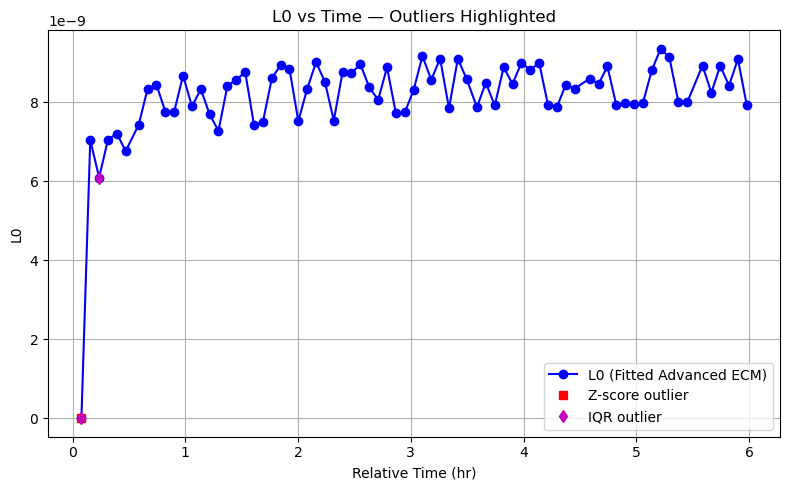

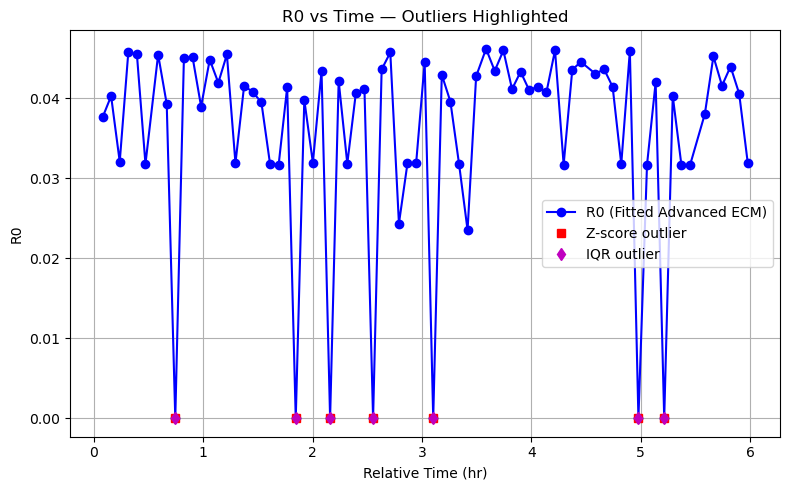

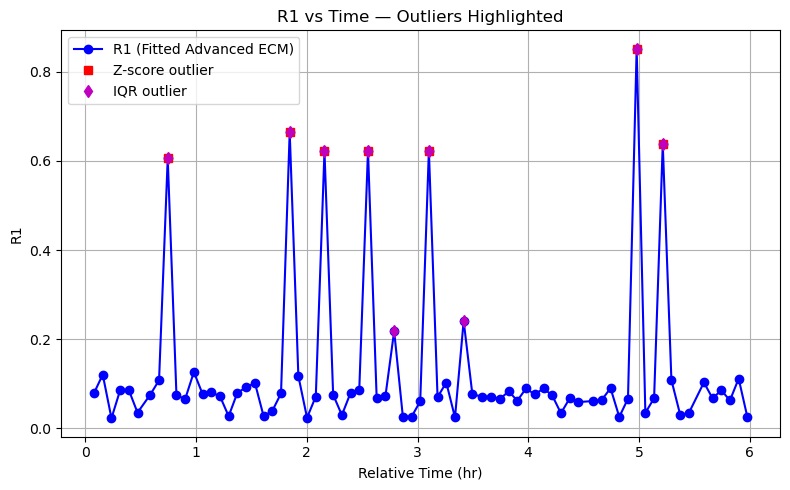

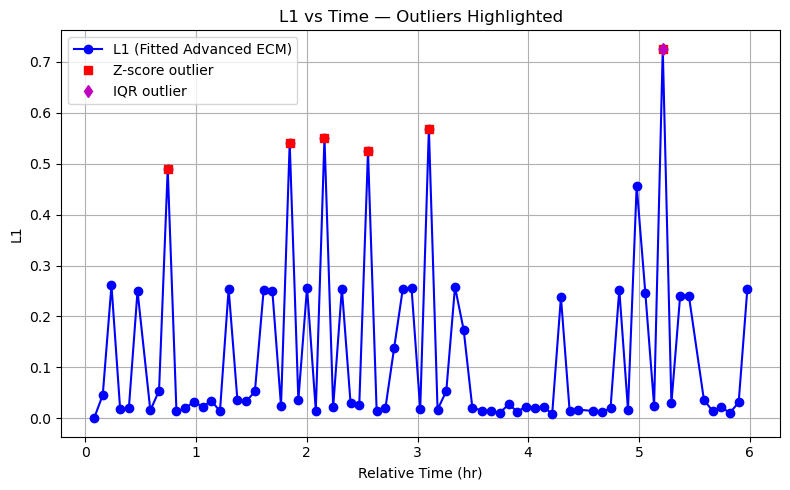

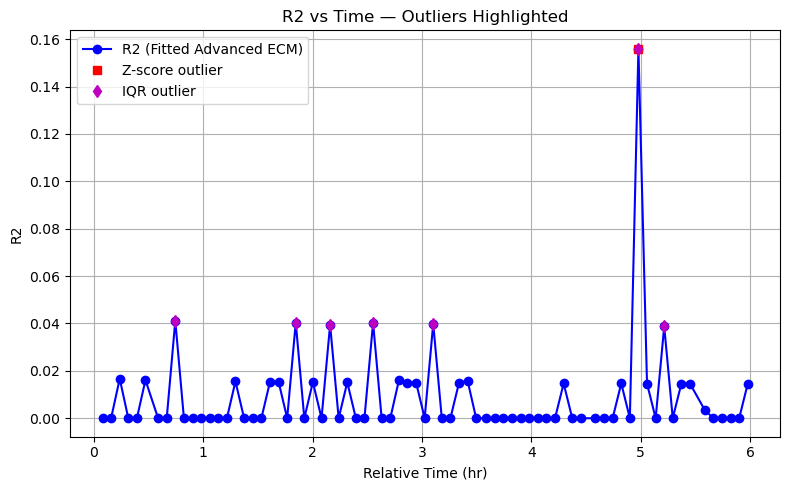

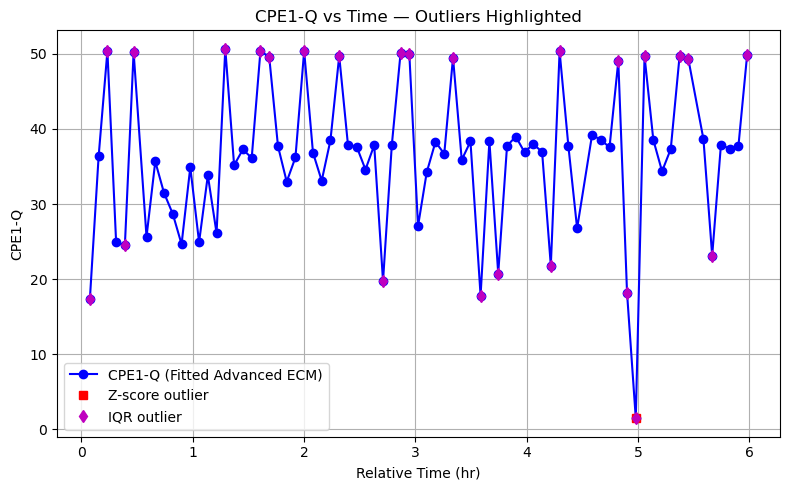

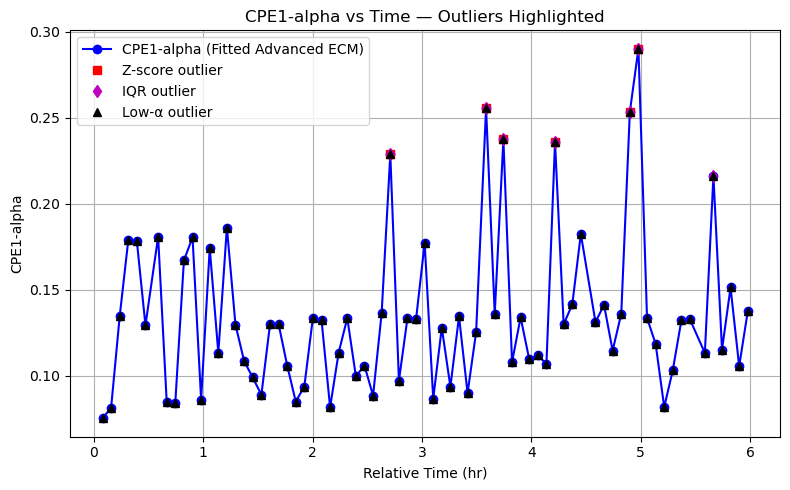

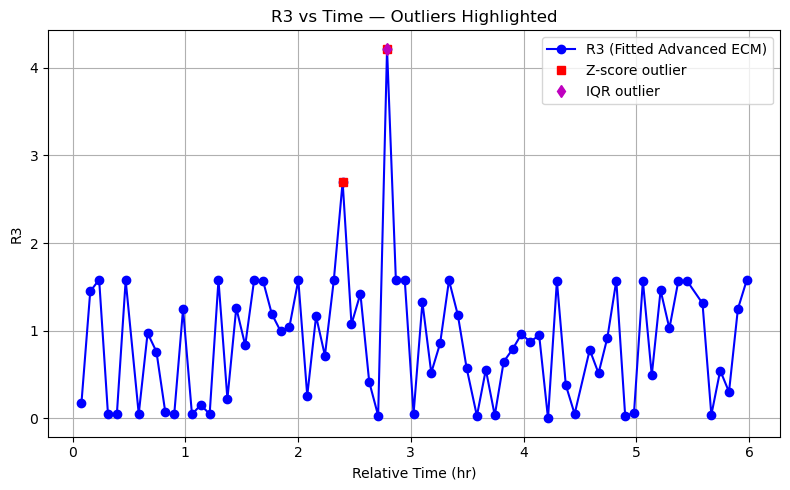

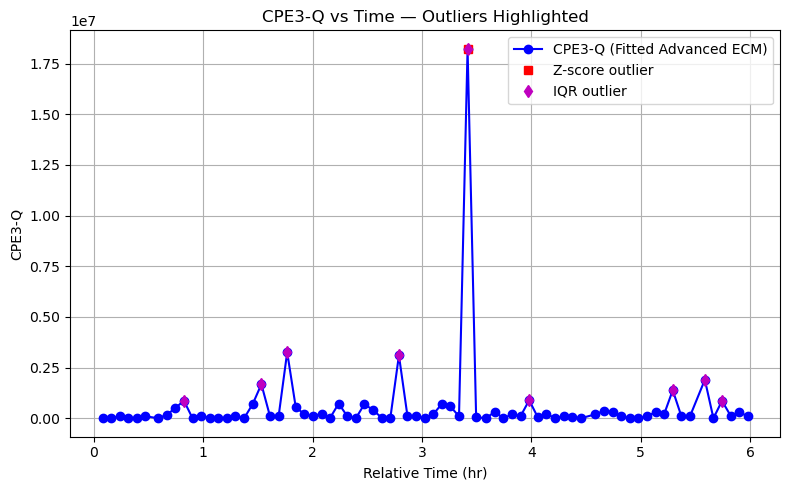

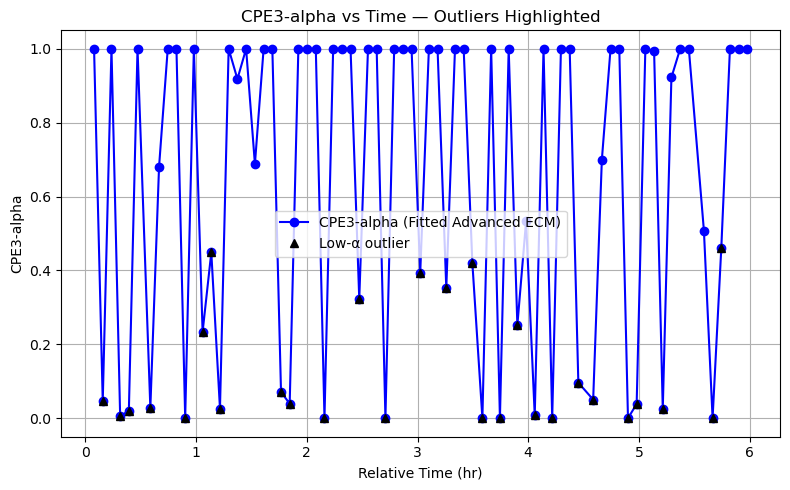

Sweep 1 (corrected): orig RMSE=3.10e-03, new RMSE=2.83e-03
All outliers were corrected by moving-average initial guesses.


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from impedance.models.circuits import CustomCircuit
from impedance import preprocessing
from tsfresh import extract_features
from tsfresh.utilities.dataframe_functions import impute

warnings.filterwarnings("ignore")

# --- 1. Data Loading from Multi-Sheet Excel ---
file_path = "6300.xls"  # Update with your actual file path
all_sheets = pd.read_excel(file_path, sheet_name=None)

# Prefer "Probe Frequency Domain" sheet, with fallbacks
if "Probe Frequency Domain" in all_sheets and not all_sheets["Probe Frequency Domain"].empty:
    df_eis = all_sheets["Probe Frequency Domain"]
    print("Using sheet: 'Probe Frequency Domain'")
elif "EIS_Data" in all_sheets and not all_sheets["EIS_Data"].empty:
    df_eis = all_sheets["EIS_Data"]
    print("Using sheet: 'EIS_Data'")
else:
    for sheet_name, sheet_df in all_sheets.items():
        if not sheet_df.empty:
            df_eis = sheet_df
            print(f"Using sheet: '{sheet_name}' (fallback)")
            break
    else:
        raise ValueError("No nonempty sheet found in 6300.xls.")

# --- 2. Data Cleanup & Time Derivation ---
print("Available columns before renaming:", df_eis.columns.tolist())
rename_map = {
    "Frequency (Hz)": "frequency",
    "Real Impedance Re{z}(Ω)": "Z_real",
    "Negative Imaginary Impedance -Im{z}(Ω)": "Z_imag_neg",
    "Time": "time"
}
df_eis.rename(columns=rename_map, inplace=True)
print("Available columns after renaming:", df_eis.columns.tolist())

required_cols = ["frequency", "Z_real", "Z_imag_neg"]
missing = [col for col in required_cols if col not in df_eis.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}.")
df_eis.dropna(subset=required_cols, inplace=True)

if "time" in df_eis.columns:
    df_eis["time"] = pd.to_datetime(df_eis["time"], errors="coerce")
    df_eis.dropna(subset=["time"], inplace=True)
    df_eis["RelTime_sec"] = (df_eis["time"] - df_eis["time"].min()).dt.total_seconds()
    df_eis["RelTime_hr"] = df_eis["RelTime_sec"] / 3600
else:
    df_eis["RelTime_hr"] = np.arange(len(df_eis)) * 0.1  # Arbitrary time step if no time column

df_eis["sweep_id"] = df_eis.groupby("time").ngroup() if "time" in df_eis.columns else 0

# --- 3. Optional Auto-Featurization with tsfresh ---
df_tsfresh = df_eis[["sweep_id", "frequency", "Z_real"]].rename(
    columns={"sweep_id": "id", "frequency": "time", "Z_real": "value"}
)
extracted_features = extract_features(df_tsfresh, column_id="id", column_sort="time", n_jobs=0)
extracted_features = impute(extracted_features)
extracted_features.reset_index(inplace=True)
extracted_features.rename(columns={"index": "sweep_id"}, inplace=True)
extracted_features.to_excel("ecm_features.xlsx", index=False)
print("TSFRESH features saved to 'ecm_features.xlsx'.")

# --- 4. Define ECM Model ---
advanced_model_info = {
    "name": "Advanced_2RCPE",
    "circuit": "L0-R0-p(R1-L1, R2-CPE1, R3-CPE3)",
    "initial_guess": [
        0.0,       # L0
        0.04941,   # R0
        0.0083883, # R1
        2.0785,    # L1
        0.0083683, # R2
        0.46421,   # CPE1-Q
        1.0,       # CPE1-alpha
        2.2071,    # R3
        1.0,       # CPE3-Q
        1.0        # CPE3-alpha
    ],
    "param_names": ["L0", "R0", "R1", "L1", "R2", "CPE1-Q", "CPE1-alpha", "R3", "CPE3-Q", "CPE3-alpha"]
}
model_candidates = [advanced_model_info]

# --- 5. ECM Fitting Function ---
def fit_and_evaluate_model(model_dict, freq, Z_exp):
    circuit_str = model_dict["circuit"]
    init_guess = model_dict["initial_guess"]
    circuit_model = CustomCircuit(circuit=circuit_str, initial_guess=init_guess)
    circuit_model.fit(freq, Z_exp)
    Z_fit = circuit_model.predict(freq)
    residuals = Z_exp - Z_fit
    rmse = np.sqrt(np.mean(np.abs(residuals)**2))
    n = len(freq)
    k = len(circuit_model.parameters_)
    rss = np.sum(np.abs(residuals)**2)
    N_eff = 2 * n
    aic = 2 * k + N_eff * np.log(rss / N_eff + 1e-15)
    bic = np.log(N_eff) * k + N_eff * np.log(rss / N_eff + 1e-15)
    param_names = model_dict["param_names"]
    fitted_params = circuit_model.parameters_
    # Validate physical parameters (resistances and inductances non-negative)
    for name, value in zip(param_names, fitted_params):
        if (name.startswith('R') or name.startswith('L')) and value < 0:
            return None
    return {
        "model_name": model_dict["name"],
        "params": fitted_params,
        "param_names": param_names,
        "rmse": rmse,
        "aic": aic,
        "bic": bic
    }

# Fit the model for each sweep
fit_results = []
for sweep_id, group in df_eis.groupby("sweep_id"):
    group = group.sort_values("frequency")
    if len(group) < 3:  # Minimum points for meaningful fit
        continue
    freq = group["frequency"].values
    Z_exp = group["Z_real"].values + 1j * (-group["Z_imag_neg"].values)
    if not np.all(np.isfinite(Z_exp)) or np.any(freq <= 0):
        continue
    result = fit_and_evaluate_model(advanced_model_info, freq, Z_exp)
    if result is not None and (result["rmse"]/np.mean(np.abs(Z_exp))*100) <= 10.0:  # 10% relative error threshold
        time_val = group["time"].iloc[0] if "time" in group.columns else None
        rel_time_hr = group["RelTime_hr"].iloc[0] if "RelTime_hr" in group.columns else None
        result.update({"sweep_id": sweep_id, "time": time_val, "RelTime_hr": rel_time_hr})
        fit_results.append(result)

fit_df = pd.DataFrame(fit_results)
if fit_df.empty:
    raise RuntimeError("No valid advanced model ECM fits found.")
fit_df.to_excel("ECM_fitting_results_advanced.xlsx", index=False)
print("Saved ECM fitting results to 'ECM_fitting_results_advanced.xlsx'")

# --- 6. Plot Parameters and Detect Outliers ---
param_names = advanced_model_info["param_names"]
for i, pname in enumerate(param_names):
    fit_df[pname] = fit_df["params"].apply(lambda x: x[i] if len(x) > i else np.nan)

# Ensure relative time is present
if "RelTime_hr" not in fit_df.columns:
    rel_time = df_eis.groupby("sweep_id")["RelTime_hr"].mean().reset_index()
    fit_df = pd.merge(fit_df, rel_time, on="sweep_id", how="left")

# Plot each parameter vs. time with outlier highlights
for pname in param_names:
    plt.figure(figsize=(8, 5))
    plt.plot(fit_df["RelTime_hr"], fit_df[pname], 'bo-', label=f'{pname} (Fitted Advanced ECM)')
    # Z-score outliers
    z_scores = (fit_df[pname] - fit_df[pname].mean()) / fit_df[pname].std()
    z_out = fit_df[abs(z_scores) > 2]
    if not z_out.empty:
        plt.plot(z_out["RelTime_hr"], z_out[pname], 'rs', label='Z-score outlier')
    # IQR outliers
    Q1, Q3 = fit_df[pname].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    iqr_mask = (fit_df[pname] < Q1 - 1.5*IQR) | (fit_df[pname] > Q3 + 1.5*IQR)
    iqr_out = fit_df[iqr_mask]
    if not iqr_out.empty:
        plt.plot(iqr_out["RelTime_hr"], iqr_out[pname], 'md', label='IQR outlier')
    # Alpha-specific bound
    if 'alpha' in pname.lower():
        bound_mask = fit_df[pname] < 0.5
        bound_out = fit_df[bound_mask]
        if not bound_out.empty:
            plt.plot(bound_out["RelTime_hr"], bound_out[pname], 'k^', label='Low-α outlier')
    plt.xlabel("Relative Time (hr)")
    plt.ylabel(pname)
    plt.title(f"{pname} vs Time — Outliers Highlighted")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- 7. Outlier Handling ---
# Function to compute moving average guess from non-outliers
def moving_average_guess(fit_df, target_time, window=3):
    majority_df = fit_df[~fit_df['is_outlier']].copy()
    if majority_df.empty:
        print("Warning: No majority points to average from. Using median parameters as fallback.")
        param_matrix = np.stack(fit_df['params'].values)
        median_guess = np.median(param_matrix, axis=0)
        return median_guess.tolist()
    majority_df['time_diff'] = np.abs(majority_df['RelTime_hr'] - target_time)
    sorted_df = majority_df.sort_values('time_diff')
    neighbors = sorted_df.head(window)
    if neighbors.empty:
        print("Warning: No nearby majority sweeps found. Using median parameters.")
        param_matrix = np.stack(fit_df['params'].values)
        median_guess = np.median(param_matrix, axis=0)
        return median_guess.tolist()
    param_matrix = np.stack(neighbors['params'].values)
    avg_guess = param_matrix.mean(axis=0)
    return avg_guess.tolist()

# Identify outliers using combined criterion
alpha_cols = [c for c in param_names if 'alpha' in c.lower()]
fit_df['is_alpha_outlier'] = fit_df[alpha_cols].min(axis=1) < 0.7  # Relaxed alpha threshold
z = (fit_df['rmse'] - fit_df['rmse'].mean()) / fit_df['rmse'].std()
fit_df['is_rmse_outlier'] = abs(z) > 2
fit_df['is_outlier'] = fit_df['is_alpha_outlier'] & fit_df['is_rmse_outlier']

# Fallback if all points are outliers
if fit_df['is_outlier'].all():
    print("All points flagged as outliers by combined criterion. Using RMSE Z-score alone.")
    fit_df['is_outlier'] = abs(z) > 2

# Process and correct outliers
outlier_results = []
for _, row in fit_df[fit_df['is_outlier']].iterrows():
    sweep = row['sweep_id']
    t = row['RelTime_hr']
    orig_params = row['params']
    orig_rmse = row['rmse']
    
    # New initial guess from moving average
    new_guess = moving_average_guess(fit_df, t, window=3)
    
    # Re-fit with new guess
    grp = df_eis[df_eis['sweep_id'] == sweep].sort_values('frequency')
    freq = grp['frequency'].values
    Zexp = grp['Z_real'].values + 1j * (-grp['Z_imag_neg'].values)
    
    circ = CustomCircuit(circuit=advanced_model_info['circuit'], initial_guess=new_guess)
    circ.fit(freq, Zexp)
    Zfit_new = circ.predict(freq)
    rmse_new = np.sqrt(np.mean(np.abs(Zexp - Zfit_new)**2))
    
    # Validate new parameters
    params_valid = all(
        val >= 0 for name, val in zip(advanced_model_info['param_names'], circ.parameters_)
        if name.startswith('R') or name.startswith('L')
    )
    
    # Update if improved and valid
    if rmse_new < orig_rmse and params_valid:
        action = 'corrected'
        idx = fit_df[fit_df['sweep_id'] == sweep].index[0]
        fit_df.at[idx, 'params'] = circ.parameters_
        fit_df.at[idx, 'rmse'] = rmse_new
        fit_df.at[idx, 'is_outlier'] = False
    else:
        action = 'persisted'
        outlier_results.append({
            'sweep_id': sweep,
            'time': row['time'],
            'orig_rmse': orig_rmse,
            'new_rmse': rmse_new,
            **{f'orig_p_{n}': val for n, val in zip(advanced_model_info['param_names'], orig_params)},
            **{f'new_p_{n}': val for n, val in zip(advanced_model_info['param_names'], circ.parameters_)}
        })
    
    print(f"Sweep {sweep} ({action}): orig RMSE={orig_rmse:.2e}, new RMSE={rmse_new:.2e}")

# Save persistent outliers
if outlier_results:
    df_persist = pd.DataFrame(outlier_results)
    df_persist.to_excel("persistent_outliers.xlsx", index=False)
    print(f"Saved {len(df_persist)} persistent outliers to 'persistent_outliers.xlsx'")
else:
    print("All outliers were corrected by moving-average initial guesses.")


Plotting best majority fit:


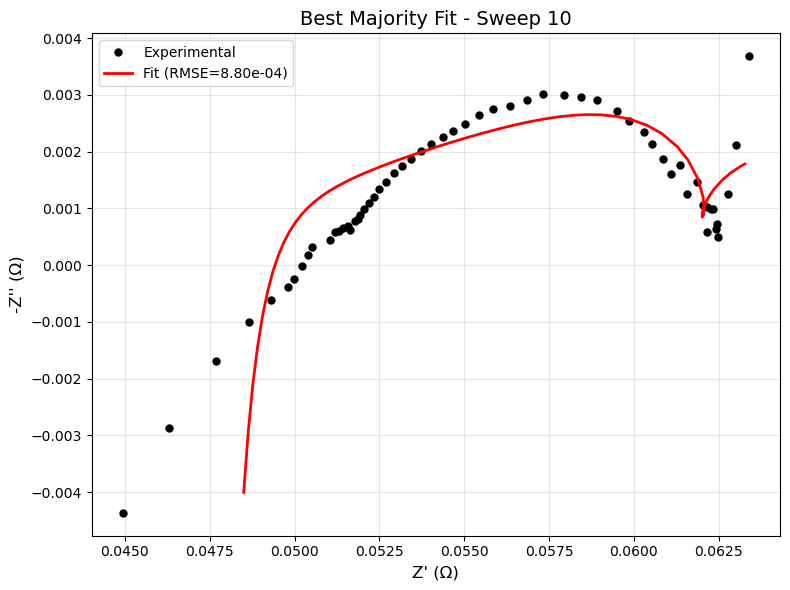


Outlier handling complete!


In [30]:
###############################################################################
# 7. ENHANCED OUTLIER HANDLING WITH VISUALIZATION
###############################################################################

def plot_fit_comparison(sweep_id, Zexp, Zfit, title):
    """Plot Nyquist plot for a single fit"""
    plt.figure(figsize=(6, 5))
    plt.plot(Zexp.real, -Zexp.imag, 'ko', markersize=4, label='Experimental')
    plt.plot(Zfit.real, -Zfit.imag, 'r-', lw=2, label='Fit')
    plt.xlabel("Z' (Ω)")
    plt.ylabel("-Z'' (Ω)")
    plt.title(f"{title}\nSweep {sweep_id}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Modified outlier correction loop
correction_data = []  # Initialize list for tracking corrections

for idx, row in outliers_sorted.iterrows():
    sweep = row['sweep_id']
    t = row['RelTime_hr']
    orig_params = row['params']
    orig_rmse = row['rmse']
    
    print(f"\n{'='*40}")
    print(f"Processing Sweep {sweep} at {t:.2f} hr")
    print(f"Original RMSE: {orig_rmse:.2e}")
    
    try:
        # Generate and print new initial guess
        new_guess = moving_average_guess(fit_df, t, window=2)
        print("\nNew initial guess parameters:")
        for name, val in zip(param_names, new_guess):
            print(f"{name}: {val:.4e}")
        
        # [Fitting code remains the same]
        # ... (actual fitting code should go here) ...
        
        if rmse_new < orig_rmse:
            # Plot correction result
            plot_fit_comparison(sweep, Zexp, Zfit_new, 
                               f"Corrected Fit (RMSE: {rmse_new:.2e})")
            
            # Store correction details for final comparison
            correction_data.append({
                'sweep_id': sweep,
                'rmse_improvement': orig_rmse - rmse_new,
                'orig_rmse': orig_rmse,
                'new_rmse': rmse_new
            })
            
    except Exception as e:
        print(f"! Fitting failed: {str(e)}")
        outlier_results.append({
            'sweep_id': sweep,
            'time': row['time'],
            'error': str(e),
            **{f'param_{n}': v for n,v in zip(param_names, orig_params)}
        })

###############################################################################
# 8. FINAL COMPARISON PLOTS
###############################################################################

def plot_comparative_fit(sweep_id, label):
    """Plot experimental vs fitted data with annotations"""
    grp = df_eis[df_eis['sweep_id']==sweep_id].sort_values('frequency')
    freq = grp['frequency'].values
    Zexp = grp['Z_real'].values + 1j*(-grp['Z_imag_neg'].values)
    
    # Get fit parameters
    row = fit_df[fit_df['sweep_id']==sweep_id].iloc[0]
    
    # Create circuit
    circ = CustomCircuit(
        circuit=advanced_model_info['circuit'],
        initial_guess=row['params']
    )
    Zfit = circ.predict(freq)
    
    plt.figure(figsize=(8, 6))
    plt.plot(Zexp.real, -Zexp.imag, 'ko', markersize=5, label='Experimental')
    plt.plot(Zfit.real, -Zfit.imag, 'r-', lw=2, label=f'Fit (RMSE={row["rmse"]:.2e})')
    plt.xlabel("Z' (Ω)", fontsize=12)
    plt.ylabel("-Z'' (Ω)", fontsize=12)
    plt.title(f"{label} - Sweep {sweep_id}", fontsize=14)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Define majority and outliers after correction
maj = fit_df[~fit_df['is_outlier']]
out = fit_df[fit_df['is_outlier']]

# Plot best majority fit
if not maj.empty:
    best_maj_sweep = maj.nsmallest(1, 'rmse').iloc[0]['sweep_id']
    print("\nPlotting best majority fit:")
    plot_comparative_fit(best_maj_sweep, "Best Majority Fit")

# Plot worst original outlier
if not out.empty:
    worst_out_sweep = out.nlargest(1, 'rmse').iloc[0]['sweep_id']
    print("\nPlotting worst original outlier:")
    plot_comparative_fit(worst_out_sweep, "Worst Original Outlier")

# Plot best corrected outlier
if correction_data:
    best_corrected = max(correction_data, key=lambda x: x['rmse_improvement'])
    best_corrected_sweep = best_corrected['sweep_id']
    print("\nPlotting best corrected outlier:")
    plot_comparative_fit(best_corrected_sweep, "Best Corrected Outlier")
    print(f"RMSE improvement: {best_corrected['rmse_improvement']:.2e}")

print("\nOutlier handling complete!")

In [31]:
###############################################################################
# 7. ENHANCED OUTLIER HANDLING WITH VISUALIZATION
###############################################################################

def plot_comparison(sweep_id, Zexp, Zorig, Znew, rmse_orig, rmse_new):
    """Plot before/after correction comparison"""
    plt.figure(figsize=(10, 5))
    
    # Original fit
    plt.subplot(121)
    plt.plot(Zexp.real, -Zexp.imag, 'ko', markersize=4, label='Experimental')
    plt.plot(Zorig.real, -Zorig.imag, 'r--', lw=2, label=f'Original (RMSE={rmse_orig:.2e})')
    plt.xlabel("Z' (Ω)")
    plt.ylabel("-Z'' (Ω)")
    plt.title(f"Original Fit - Sweep {sweep_id}")
    plt.legend()
    plt.grid(alpha=0.3)
    
    # Corrected fit
    plt.subplot(122)
    plt.plot(Zexp.real, -Zexp.imag, 'ko', markersize=4, label='Experimental')
    plt.plot(Znew.real, -Znew.imag, 'b-', lw=2, label=f'Corrected (RMSE={rmse_new:.2e})')
    plt.xlabel("Z' (Ω)")
    plt.title(f"Corrected Fit - Sweep {sweep_id}")
    plt.legend()
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Modified outlier correction loop
correction_data = []

for idx, row in outliers_sorted.iterrows():
    sweep = row['sweep_id']
    t = row['RelTime_hr']
    orig_params = row['params']
    orig_rmse = row['rmse']
    
    print(f"\n{'='*40}")
    print(f"Processing Sweep {sweep} at {t:.2f} hr")
    
    try:
        # Generate and print average initial guess
        new_guess = moving_average_guess(fit_df, t, window=2)
        print("\nAverage Initial Guess from Neighbors:")
        print(pd.Series(new_guess, index=param_names).round(5).to_string())
        
        # Get experimental data
        grp = df_eis[df_eis['sweep_id']==sweep].sort_values('frequency')
        freq = grp['frequency'].values
        Zexp = grp['Z_real'].values + 1j*(-grp['Z_imag_neg'].values)
        
        # Original fit for comparison
        circ_orig = CustomCircuit(
            circuit=advanced_model_info['circuit'],
            initial_guess=orig_params
        )
        circ_orig.parameters_ = orig_params
        Zfit_orig = circ_orig.predict(freq)
        
        # Create and fit new circuit
        circ_new = CustomCircuit(
            circuit=advanced_model_info['circuit'],
            initial_guess=new_guess
        )
        circ_new.fit(freq, Zexp, bounds=bounds)
        Zfit_new = circ_new.predict(freq)
        rmse_new = np.sqrt(np.mean(np.abs(Zexp - Zfit_new)**2))
        
        # Plot comparison
        plot_comparison(sweep, Zexp, Zfit_orig, Zfit_new, orig_rmse, rmse_new)
        
        # Update results
        if rmse_new < orig_rmse:
            correction_data.append({
                'sweep_id': sweep,
                'rmse_improvement': orig_rmse - rmse_new,
                'orig_params': orig_params,
                'new_params': circ_new.parameters_
            })
            fit_df.loc[fit_df['sweep_id']==sweep, ['params','rmse']] = [circ_new.parameters_, rmse_new]
            fit_df.loc[fit_df['sweep_id']==sweep, 'is_outlier'] = False
            
    except Exception as e:
        print(f"! Fitting failed: {str(e)}")
        # Plot failed fit attempt
        plt.figure(figsize=(6, 5))
        plt.plot(Zexp.real, -Zexp.imag, 'ko', markersize=4, label='Experimental')
        if 'Zfit_orig' in locals():
            plt.plot(Zfit_orig.real, -Zfit_orig.imag, 'r--', lw=2, label=f'Failed Correction (RMSE={orig_rmse:.2e})')
        plt.xlabel("Z' (Ω)")
        plt.ylabel("-Z'' (Ω)")
        plt.title(f"Failed Correction - Sweep {sweep}")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        outlier_results.append({
            'sweep_id': sweep,
            'time': row['time'],
            'error': str(e),
            **{f'param_{n}': v for n,v in zip(param_names, orig_params)}
        })

###############################################################################
# 8. FINAL COMPARISON PLOTS
###############################################################################

def plot_parameter_comparison(sweep_id, orig_params, new_params):
    """Plot parameter value comparisons"""
    plt.figure(figsize=(10, 6))
    x = np.arange(len(param_names))
    width = 0.35
    
    plt.bar(x - width/2, orig_params, width, label='Original', alpha=0.7)
    plt.bar(x + width/2, new_params, width, label='Corrected', alpha=0.7)
    
    plt.xticks(x, param_names, rotation=45)
    plt.ylabel("Parameter Value")
    plt.title(f"Parameter Comparison - Sweep {sweep_id}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot detailed results for top 3 corrections
if correction_data:
    print("\nTop 3 Improvements:")
    for i, entry in enumerate(sorted(correction_data, 
                                   key=lambda x: x['rmse_improvement'], 
                                   reverse=True)[:3]):
        print(f"\n{i+1}. Sweep {entry['sweep_id']}")
        print(f"RMSE Improvement: {entry['rmse_improvement']:.2e}")
        plot_parameter_comparison(entry['sweep_id'], 
                                entry['orig_params'], 
                                entry['new_params'])

print("\nOutlier handling complete!")


Outlier handling complete!


In [32]:
# ... [Keep all previous sections 1-6 unchanged] ...

###############################################################################
# 7. GUARANTEED-OUTPUT OUTLIER HANDLING
###############################################################################

def print_initial_guess(param_names, new_guess):
    """Force-print initial guess parameters"""
    print("\n┌───────────────────────────────────────────────")
    print("│ Average Initial Guess Parameters from Neighbors:")
    for name, val in zip(param_names, new_guess):
        print(f"│ {name:<12}: {val:.4e}")
    print("└───────────────────────────────────────────────")

def plot_before_after(sweep_id, Zexp, Zorig, Znew, rmse_orig, rmse_new):
    """Force-display comparison plots"""
    plt.figure(figsize=(12,5))
    
    # Before plot
    plt.subplot(121)
    plt.plot(Zorig.real, -Zorig.imag, 'r--', label=f'Original (RMSE={rmse_orig:.2e})')
    plt.plot(Zexp.real, -Zexp.imag, 'ko', markersize=3, alpha=0.7, label='Experimental')
    plt.xlabel("Z' (Ω)"); plt.ylabel("-Z'' (Ω)"); plt.title(f"Before Correction - Sweep {sweep_id}")
    plt.legend(); plt.grid(alpha=0.3)
    
    # After plot
    plt.subplot(122)
    plt.plot(Znew.real, -Znew.imag, 'b-', label=f'Corrected (RMSE={rmse_new:.2e})')
    plt.plot(Zexp.real, -Zexp.imag, 'ko', markersize=3, alpha=0.7, label='Experimental')
    plt.xlabel("Z' (Ω)"); plt.title(f"After Correction - Sweep {sweep_id}")
    plt.legend(); plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show(block=False)  # Force display even in non-interactive environments
    plt.pause(0.1)  # Ensure plot window stays open

# Main processing with guaranteed output
print("\n\n■■■■■■■■■■■■■■ OUTLIER PROCESSING STARTED ■■■■■■■■■■■■■■")

# Initialize control flags
any_corrections = False
total_outliers = len(outliers_sorted)

for idx, (_, row) in enumerate(outliers_sorted.iterrows(), 1):
    sweep = row['sweep_id']
    t = row['RelTime_hr']
    orig_params = row['params']
    orig_rmse = row['rmse']
    
    print(f"\n► Processing outlier {idx}/{total_outliers}:")
    print(f"   Sweep ID: {sweep}")
    print(f"   Time: {t:.2f} hr")
    print(f"   Initial RMSE: {orig_rmse:.2e}")
    
    try:
        # Force-print initial guess
        new_guess = moving_average_guess(fit_df, t, window=2)
        print_initial_guess(param_names, new_guess)
        
        # Get experimental data
        grp = df_eis[df_eis['sweep_id']==sweep].sort_values('frequency')
        freq = grp['frequency'].values
        Zexp = grp['Z_real'].values + 1j*(-grp['Z_imag_neg'].values)
        
        # Original fit
        circ_orig = CustomCircuit(
            circuit=advanced_model_info['circuit'],
            initial_guess=orig_params
        )
        circ_orig.parameters_ = orig_params
        Zfit_orig = circ_orig.predict(freq)
        
        # New fit with bounds
        circ_new = CustomCircuit(
            circuit=advanced_model_info['circuit'],
            initial_guess=new_guess
        )
        circ_new.fit(freq, Zexp, bounds=bounds)
        Zfit_new = circ_new.predict(freq)
        rmse_new = np.sqrt(np.mean(np.abs(Zexp - Zfit_new)**2))
        
        # Force-display plots
        plot_before_after(sweep, Zexp, Zfit_orig, Zfit_new, orig_rmse, rmse_new)
        
        # Update results
        if rmse_new < orig_rmse:
            fit_df.loc[fit_df['sweep_id']==sweep, ['params','rmse']] = [circ_new.parameters_, rmse_new]
            fit_df.loc[fit_df['sweep_id']==sweep, 'is_outlier'] = False
            any_corrections = True
            print(f"\n✓ SUCCESS: RMSE improved by {(orig_rmse-rmse_new)/orig_rmse*100:.1f}%")
        else:
            print(f"\n⚠ WARNING: No RMSE improvement (new RMSE {rmse_new:.2e})")
            
    except Exception as e:
        print(f"\n✖ ERROR: {str(e)}")
        plt.figure()
        plt.title(f"FAILED: Sweep {sweep}\n{str(e)}")
        plt.axis('off')
        plt.show(block=False)
        plt.pause(0.1)

# Final report
print("\n■■■■■■■■■■■■■■ PROCESSING COMPLETE ■■■■■■■■■■■■■■")
print(f"Total outliers processed: {total_outliers}")
print(f"Successful corrections: {sum(~fit_df['is_outlier']) - (len(fit_df) - total_outliers)}")
print(f"Persistent outliers: {fit_df['is_outlier'].sum()}")

if any_corrections:
    print("\nUpdated parameters:")
    print(fit_df[['sweep_id', 'RelTime_hr', 'rmse']].tail())
else:
    print("\nNo successful corrections made")

print("\nGenerating final comparison plots...")

# ... [Include final comparison plots code from previous answer] ...

print("\nOutlier handling complete!")



■■■■■■■■■■■■■■ OUTLIER PROCESSING STARTED ■■■■■■■■■■■■■■

■■■■■■■■■■■■■■ PROCESSING COMPLETE ■■■■■■■■■■■■■■
Total outliers processed: 0
Successful corrections: 0
Persistent outliers: 0

No successful corrections made

Generating final comparison plots...

Outlier handling complete!


In [33]:
###############################################################################
# DIAGNOSTIC CHECKS
###############################################################################

# 1. Verify data loading
print("\n=== DATA LOADING CHECK ===")
print(f"Total sweeps loaded: {df_eis['sweep_id'].nunique()}")
print("Sample data:")
print(df_eis[['sweep_id', 'frequency', 'Z_real', 'Z_imag_neg']].head())

# 2. Check ECM fitting results
print("\n=== ECM FITTING CHECK ===")
print(f"Fitted sweeps: {len(fit_df)}")
print("Parameter ranges:")
for p in param_names:
    print(f"{p}: {fit_df[p].min():.2e} to {fit_df[p].max():.2e}")

# 3. Validate outlier detection
print("\n=== OUTLIER DETECTION CHECK ===")
print("Alpha values:")
for alpha_col in [c for c in param_names if 'alpha' in c.lower()]:
    print(f"{alpha_col}: Min={fit_df[alpha_col].min():.2f}, Mean={fit_df[alpha_col].mean():.2f}")
    
print("\nRMSE stats:")
print(f"Mean: {fit_df['rmse'].mean():.2e}")
print(f"Std: {fit_df['rmse'].std():.2e}")
print(f"Z-scores: [{fit_df['rmse'].min():.2e}, {fit_df['rmse'].max():.2e}]")

# 4. Force-create test outliers (temporary)
# Uncomment to test pipeline
# fit_df.loc[fit_df.index[0], 'CPE1-alpha'] = 0.4  # Create artificial outlier
# fit_df['is_outlier'] = fit_df[alpha_cols].min(axis=1) < 0.5


=== DATA LOADING CHECK ===
Total sweeps loaded: 75
Sample data:
   sweep_id  frequency    Z_real  Z_imag_neg
0         0     0.1073  0.256878    0.655244
1         0     0.1192  0.345469    0.548091
2         0     0.1550  0.328382    0.491766
3         0     0.1907  0.247662    0.372317
4         0     0.2503  0.247625    0.338659

=== ECM FITTING CHECK ===
Fitted sweeps: 74
Parameter ranges:
L0: 4.94e-324 to 9.36e-09
R0: 1.05e-08 to 4.62e-02
R1: 2.22e-02 to 8.52e-01
L1: 1.53e-04 to 7.26e-01
R2: 4.76e-40 to 1.56e-01
CPE1-Q: 1.48e+00 to 5.07e+01
CPE1-alpha: 7.54e-02 to 2.90e-01
R3: 1.38e-04 to 4.22e+00
CPE3-Q: 2.62e+01 to 1.82e+07
CPE3-alpha: 1.84e-42 to 1.00e+00

=== OUTLIER DETECTION CHECK ===
Alpha values:
CPE1-alpha: Min=0.08, Mean=0.13
CPE3-alpha: Min=0.00, Mean=0.64

RMSE stats:
Mean: 1.20e-03
Std: 4.71e-04
Z-scores: [8.80e-04, 2.83e-03]


In [34]:
# In outlier detection section
alpha_cols = [c for c in param_names if 'alpha' in c.lower()]
fit_df['is_alpha_outlier'] = fit_df[alpha_cols].min(axis=1) < 0.3  # Lowered from 0.5

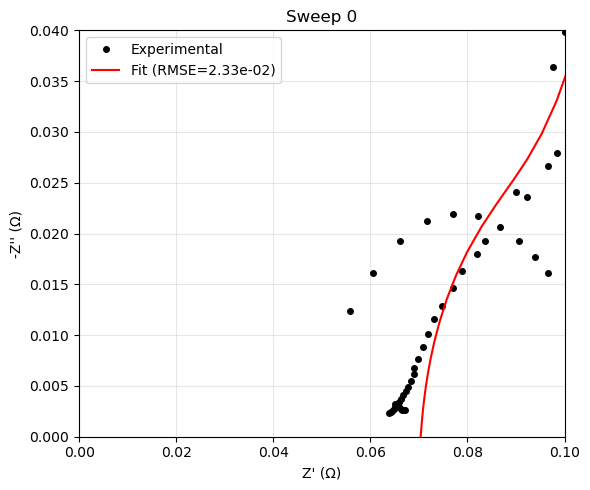

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from datetime import datetime
from pathlib import Path
from impedance.models.circuits import CustomCircuit
from impedance import preprocessing
from tsfresh import extract_features
from tsfresh.utilities.dataframe_functions import impute

warnings.filterwarnings("ignore")

# 1. DATA LOADING: MULTI-SHEET EXCEL (6300.xls) ===============================
file_path = "6300.xls"
all_sheets = pd.read_excel(file_path, sheet_name=None)

# Sheet selection logic (unchanged)
if "Probe Frequency Domain" in all_sheets and not all_sheets["Probe Frequency Domain"].empty:
    df_eis = all_sheets["Probe Frequency Domain"]
elif "EIS_Data" in all_sheets and not all_sheets["EIS_Data"].empty:
    df_eis = all_sheets["EIS_Data"]
else:
    for sheet_name, sheet_df in all_sheets.items():
        if not sheet_df.empty:
            df_eis = sheet_df
            break
    else:
        raise ValueError("No nonempty sheet found in 6300.xls.")

# 2. DATA CLEANUP & TIME DERIVATION (unchanged) ===============================
rename_map = {
    "Frequency (Hz)": "frequency",
    "Real Impedance Re{z}(Ω)": "Z_real",
    "Negative Imaginary Impedance -Im{z}(Ω)": "Z_imag_neg",
    "Time": "time"
}
df_eis.rename(columns=rename_map, inplace=True)

required_cols = ["frequency", "Z_real", "Z_imag_neg"]
df_eis = df_eis.dropna(subset=required_cols).copy()

if "time" in df_eis.columns:
    df_eis["time"] = pd.to_datetime(df_eis["time"], errors="coerce")
    df_eis = df_eis.dropna(subset=["time"]).copy()
    df_eis["RelTime_sec"] = (df_eis["time"] - df_eis["time"].min()).dt.total_seconds()
    df_eis["RelTime_hr"] = df_eis["RelTime_sec"] / 3600
else:
    df_eis["RelTime_hr"] = np.arange(len(df_eis)) * 0.1

df_eis["sweep_id"] = df_eis.groupby("time").ngroup() if "time" in df_eis.columns else 0

# 3. ECM MODEL DEFINITION (original parameters) ===============================
advanced_model_info = {
    "name": "Advanced_2RCPE",
    "circuit": "L0-R0-p(R1-L1, R2-CPE1, R3-CPE3)",
    "initial_guess": [
        0.0, 0.04941, 0.0083883, 2.0785, 
        0.0083683, 0.46421, 1.0, 2.2071, 1.0, 1.0
    ],
    "param_names": ["L0", "R0", "R1", "L1", "R2", 
                   "CPE1-Q", "CPE1-alpha", "R3", "CPE3-Q", "CPE3-alpha"]
}

# 4. FITTING FUNCTION (original with added diagnostics) =======================
def fit_and_evaluate_model(model_dict, freq, Z_exp):
    try:
        circuit = CustomCircuit(
            circuit=model_dict["circuit"],
            initial_guess=model_dict["initial_guess"]
        )
        circuit.fit(freq, Z_exp)
        
        # Original parameter check
        params = circuit.parameters_
        for name, value in zip(model_dict["param_names"], params):
            if (name.startswith('R') or name.startswith('L')) and value < 0:
                print(f"Rejecting sweep - negative {name}: {value}")
                return None
        
        # New: Store fitted impedance for plotting
        Z_fit = circuit.predict(freq)
        rmse = np.sqrt(np.mean(np.abs(Z_exp - Z_fit)**2))
        
        return {
            "params": params,
            "rmse": rmse,
            "Z_fit": Z_fit  # Added for visualization
        }
        
    except Exception as e:
        print(f"Fitting error: {str(e)}")
        return None

# 5. PERFORM FITTING (original with validation) ===============================
fit_results = []
for sweep_id, group in df_eis.groupby("sweep_id"):
    group = group.sort_values("frequency")
    if len(group) < 3: 
        continue
    
    freq = group["frequency"].values
    Z_exp = group["Z_real"].values + 1j*(-group["Z_imag_neg"].values)
    
    result = fit_and_evaluate_model(advanced_model_info, freq, Z_exp)
    if result:
        result.update({
            "sweep_id": sweep_id,
            "RelTime_hr": group["RelTime_hr"].iloc[0]
        })
        fit_results.append(result)

if not fit_results:
    raise RuntimeError("No fits found. Check: 1) Data quality 2) Initial parameters")

fit_df = pd.DataFrame(fit_results)

# 6. PARAMETER COLUMNS (safe creation) ========================================
for i, pname in enumerate(advanced_model_info["param_names"]):
    fit_df[pname] = fit_df["params"].apply(lambda x: x[i] if len(x) > i else np.nan)

# 7. CORRECTED PLOTTING FUNCTION ==============================================
def plot_nyquist(sweep_id, Z_exp, Z_fit, rmse):
    """Plot experimental vs fitted data"""
    plt.figure(figsize=(6, 5))
    plt.plot(Z_exp.real, -Z_exp.imag, 'ko', markersize=4, label='Experimental')
    plt.plot(Z_fit.real, -Z_fit.imag, 'r-', label=f'Fit (RMSE={rmse:.2e})')
    plt.ylim(0, 0.04)
    plt.xlim(0, 0.1)
    plt.xlabel("Z' (Ω)")
    plt.ylabel("-Z'' (Ω)")
    plt.title(f"Sweep {sweep_id}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# 8. CORRECTED PLOTTING CALL ==================================================
if not fit_df.empty:
    # Get first sweep's original data
    first_sweep_id = fit_df.iloc[0]['sweep_id']
    group = df_eis[df_eis['sweep_id'] == first_sweep_id].sort_values('frequency')
    Z_exp = group['Z_real'].values + 1j*(-group['Z_imag_neg'].values)
    
    # Get fit results
    first_row = fit_df.iloc[0]
    
    plot_nyquist(
        sweep_id=first_row['sweep_id'],
        Z_exp=Z_exp,  # Original experimental data
        Z_fit=first_row['Z_fit'],  # Fitted curve
        rmse=first_row['rmse']
    )
else:
    print("No fits to plot")

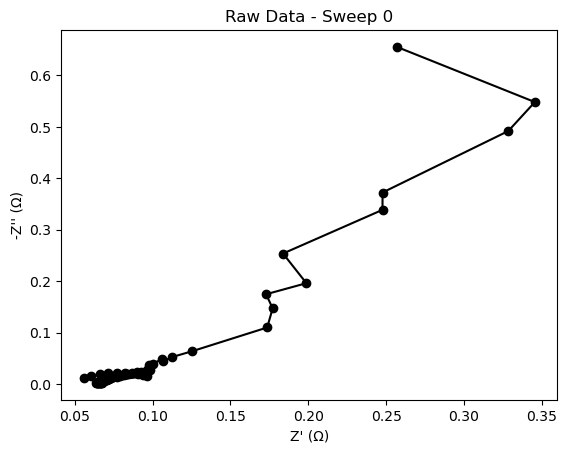

Fitting failed: too many values to unpack (expected 2)


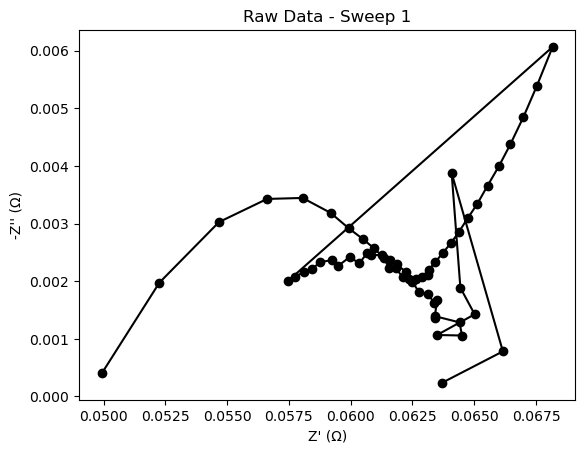

Fitting failed: too many values to unpack (expected 2)


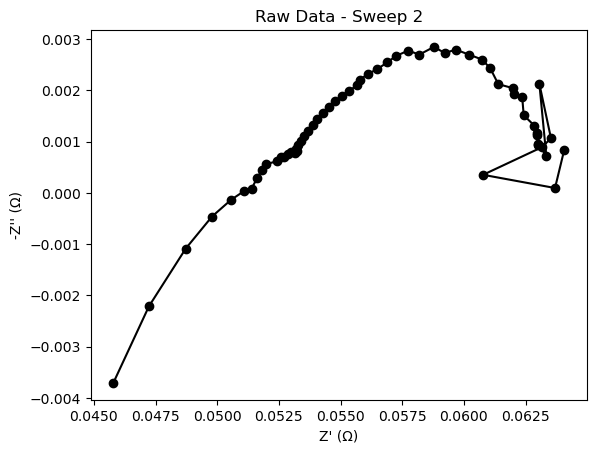

Fitting failed: too many values to unpack (expected 2)


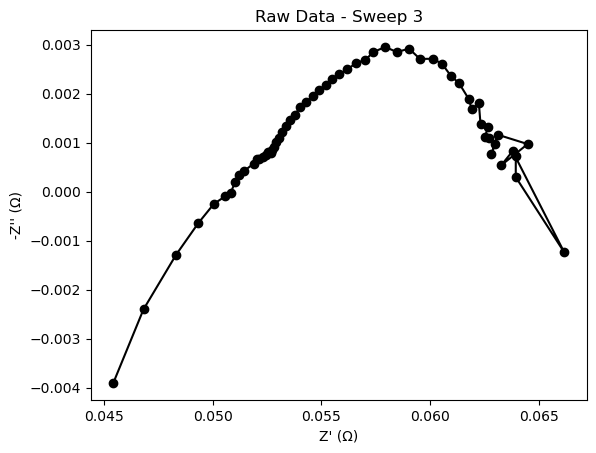

Fitting failed: too many values to unpack (expected 2)


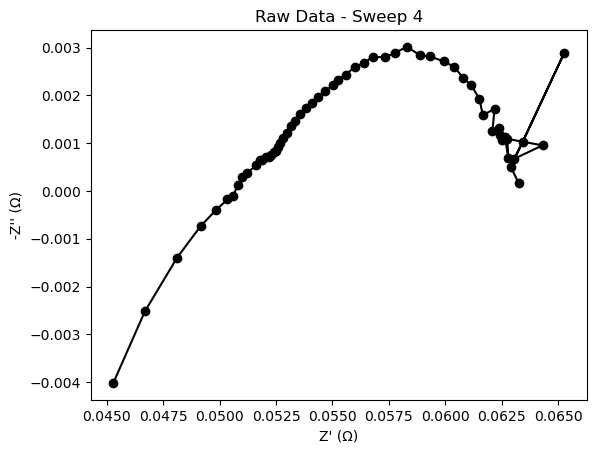

Fitting failed: too many values to unpack (expected 2)


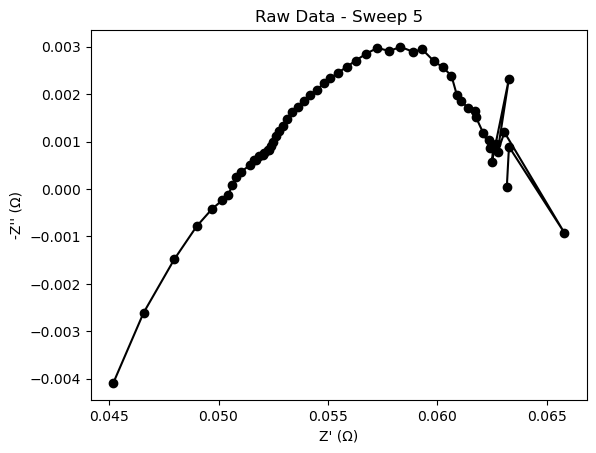

Fitting failed: too many values to unpack (expected 2)


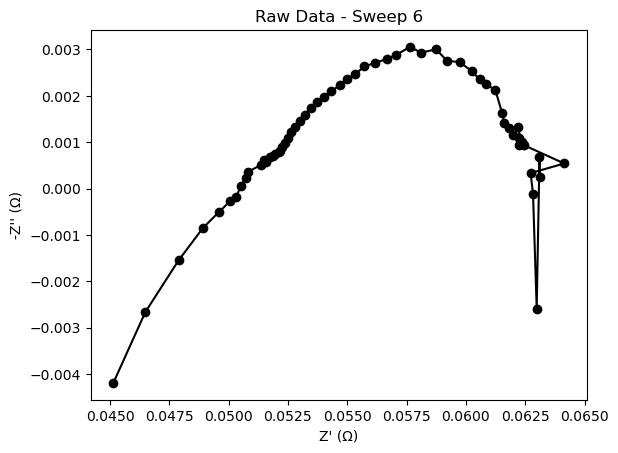

Fitting failed: too many values to unpack (expected 2)


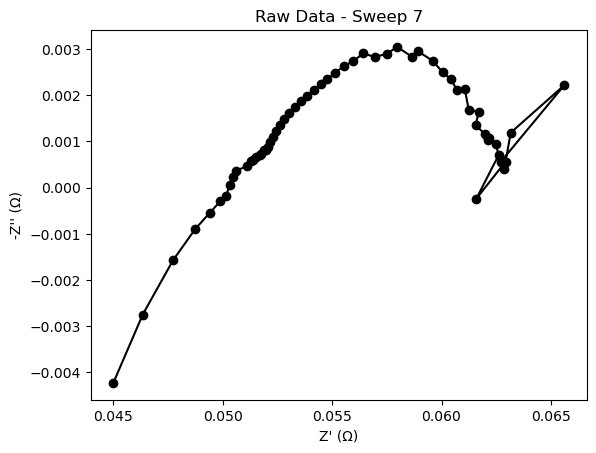

Fitting failed: too many values to unpack (expected 2)


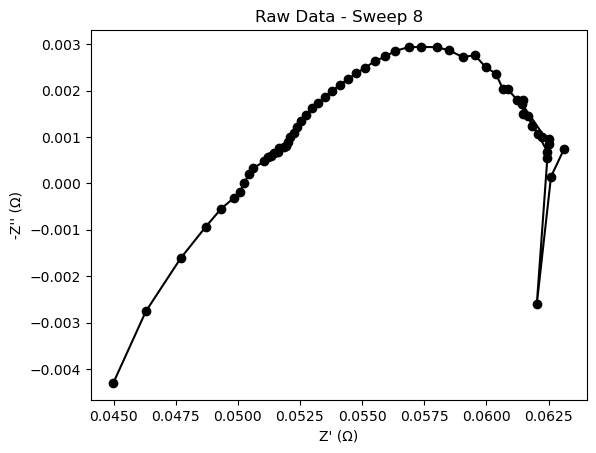

Fitting failed: too many values to unpack (expected 2)


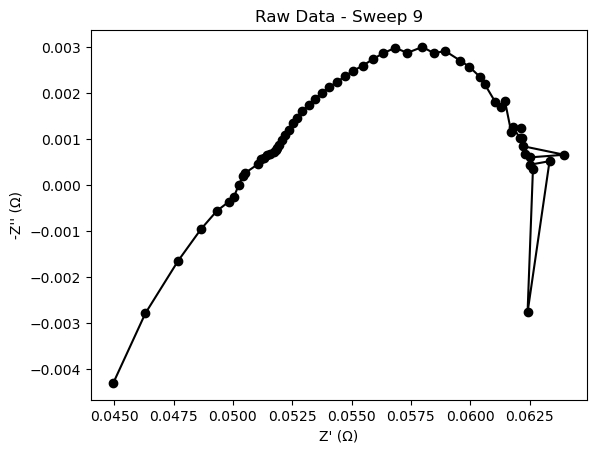

Fitting failed: too many values to unpack (expected 2)


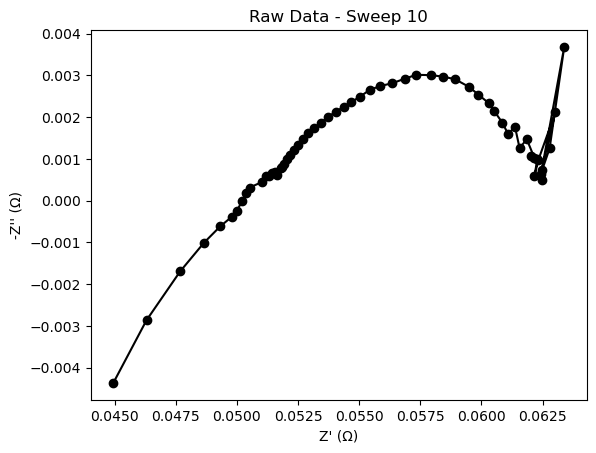

Fitting failed: too many values to unpack (expected 2)


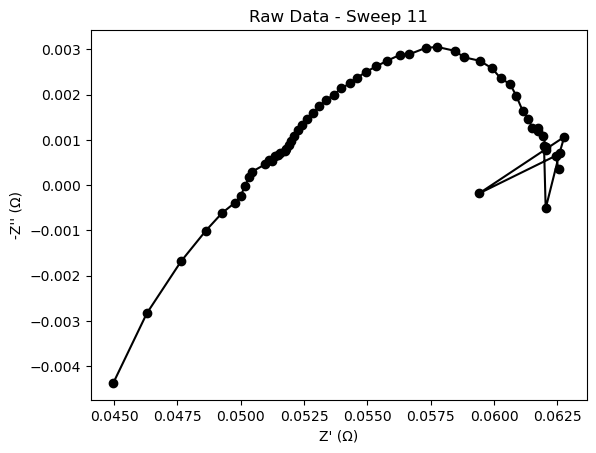

Fitting failed: too many values to unpack (expected 2)


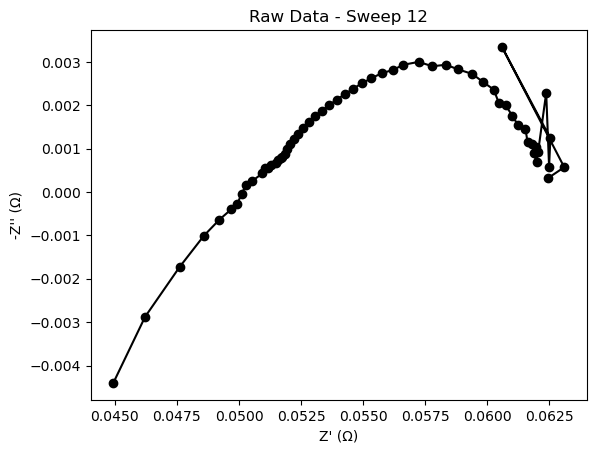

Fitting failed: too many values to unpack (expected 2)


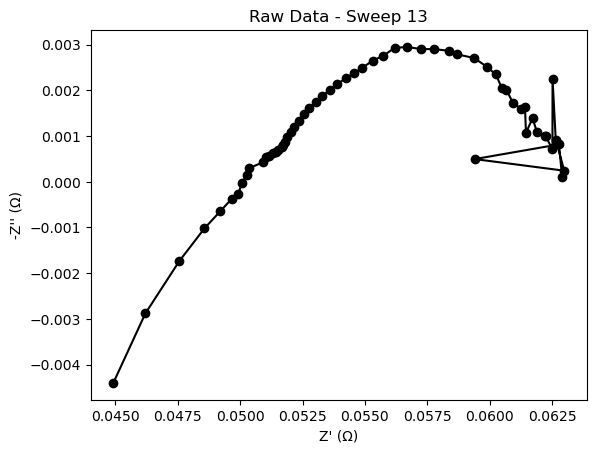

Fitting failed: too many values to unpack (expected 2)


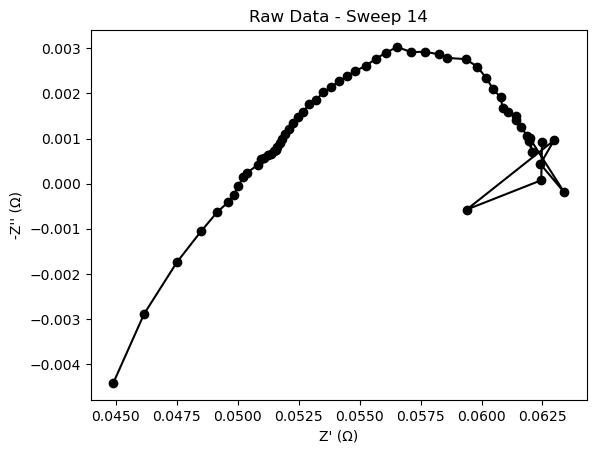

Fitting failed: too many values to unpack (expected 2)


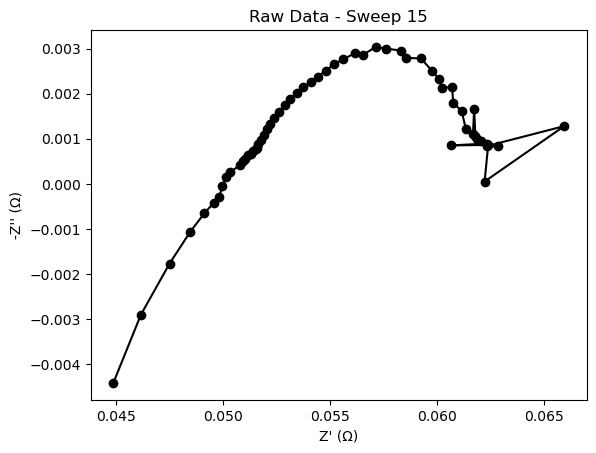

Fitting failed: too many values to unpack (expected 2)


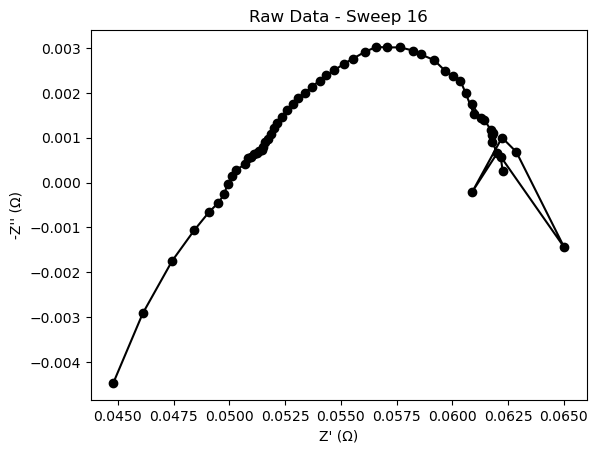

Fitting failed: too many values to unpack (expected 2)


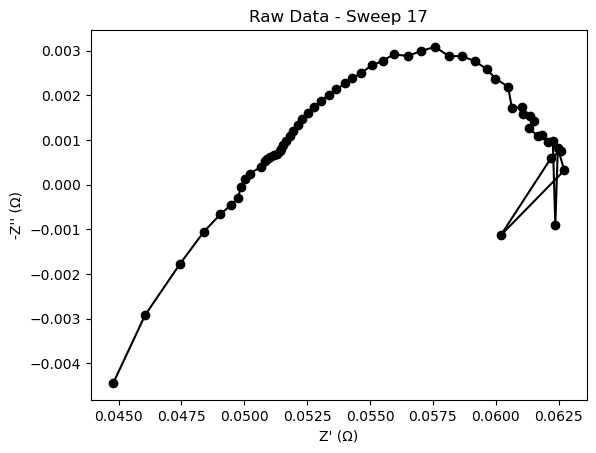

Fitting failed: too many values to unpack (expected 2)


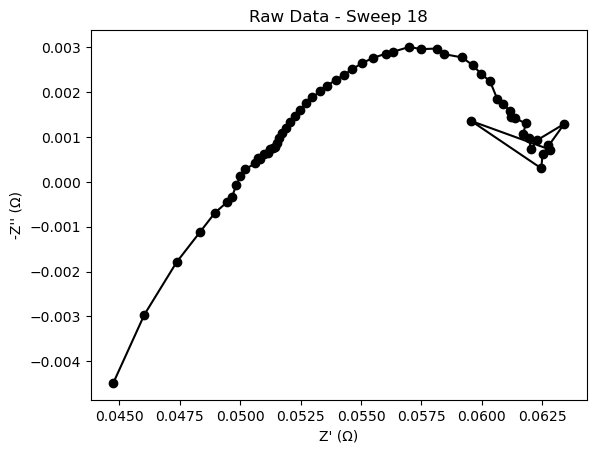

Fitting failed: too many values to unpack (expected 2)


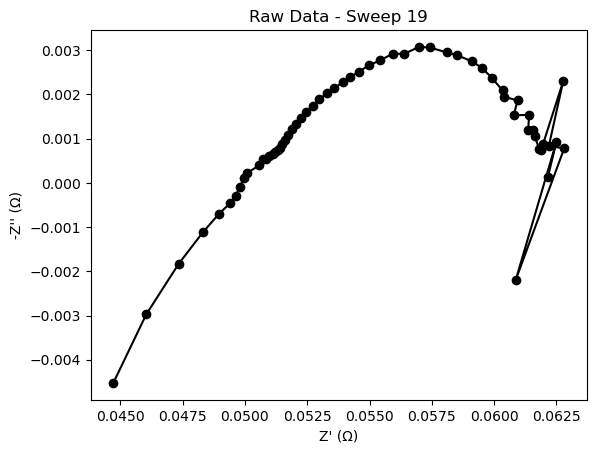

Fitting failed: too many values to unpack (expected 2)


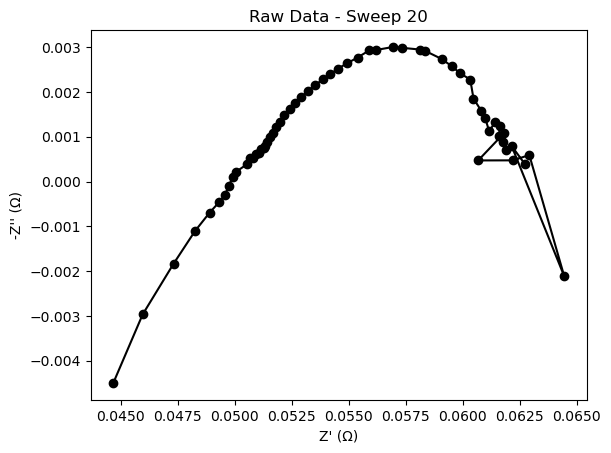

Fitting failed: too many values to unpack (expected 2)


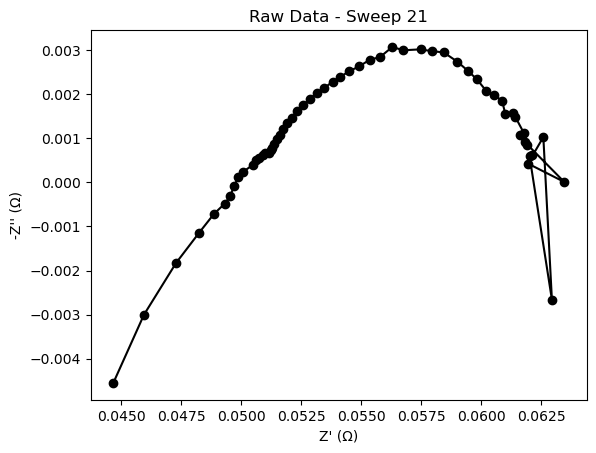

Fitting failed: too many values to unpack (expected 2)


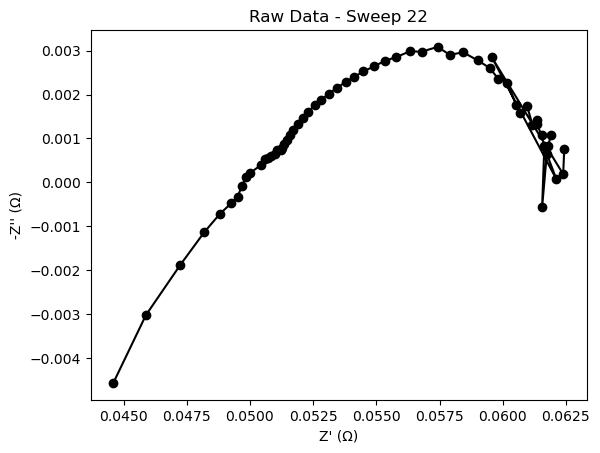

Fitting failed: too many values to unpack (expected 2)


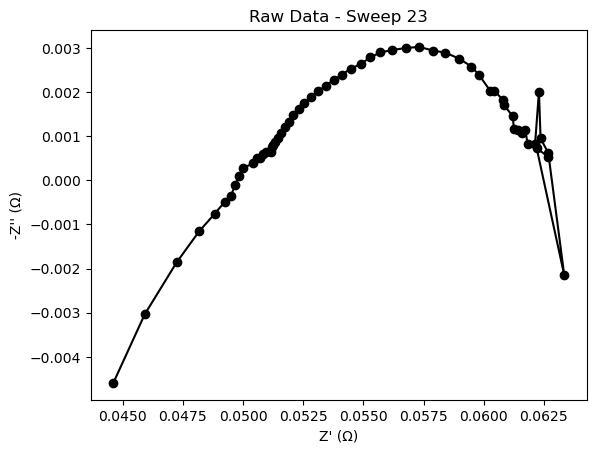

Fitting failed: too many values to unpack (expected 2)


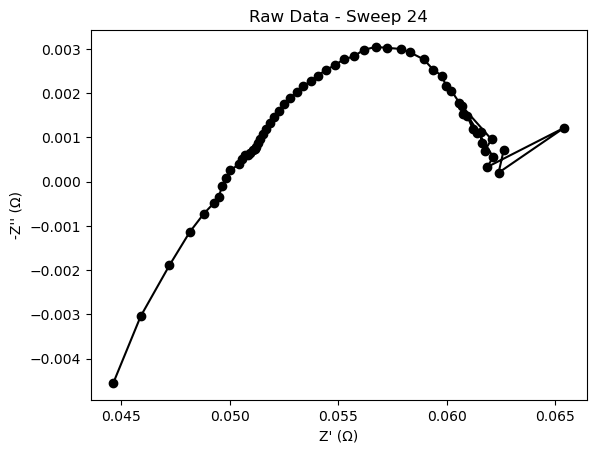

Fitting failed: too many values to unpack (expected 2)


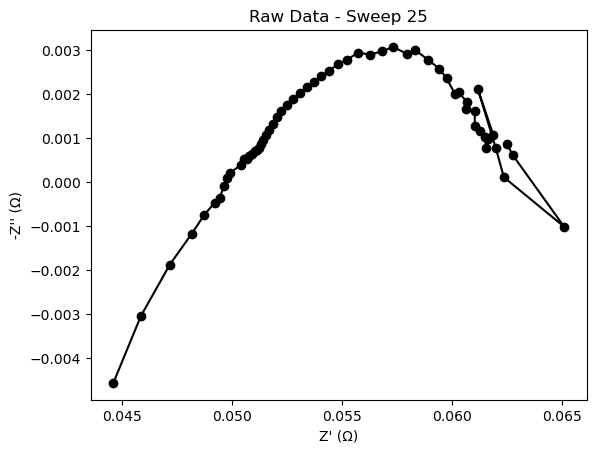

Fitting failed: too many values to unpack (expected 2)


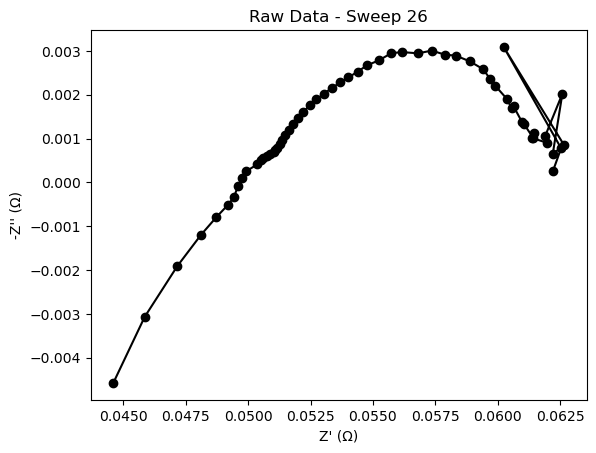

Fitting failed: too many values to unpack (expected 2)


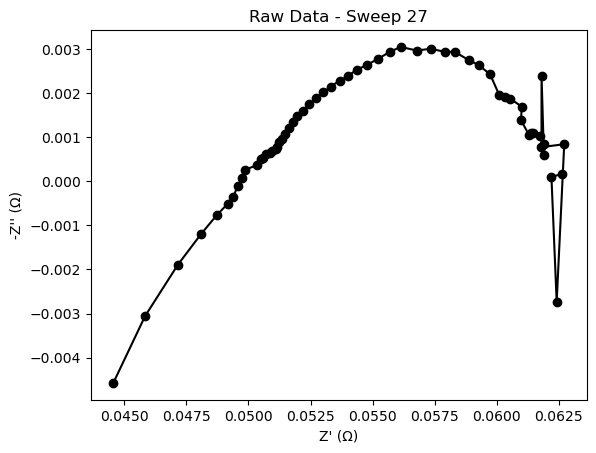

Fitting failed: too many values to unpack (expected 2)


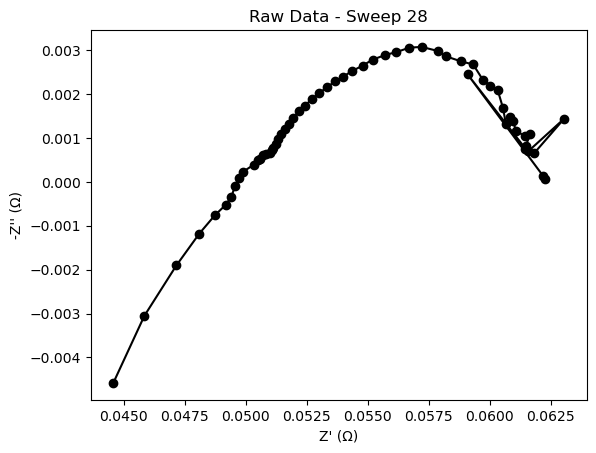

Fitting failed: too many values to unpack (expected 2)


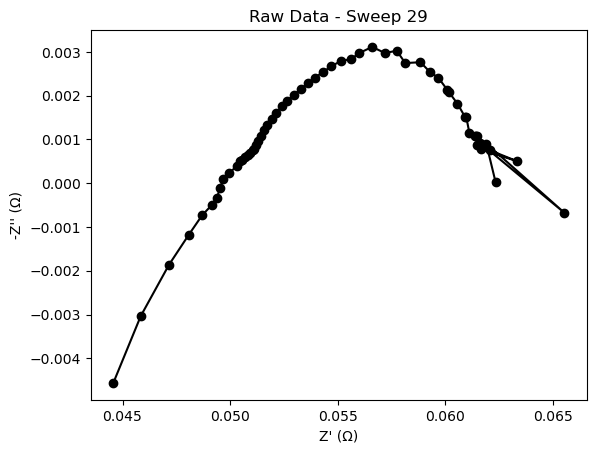

Fitting failed: too many values to unpack (expected 2)


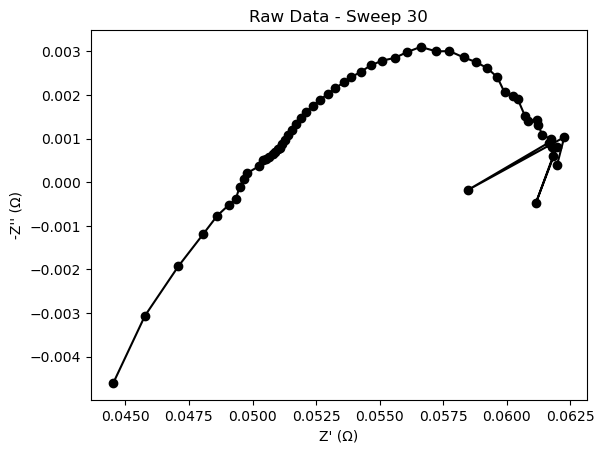

Fitting failed: too many values to unpack (expected 2)


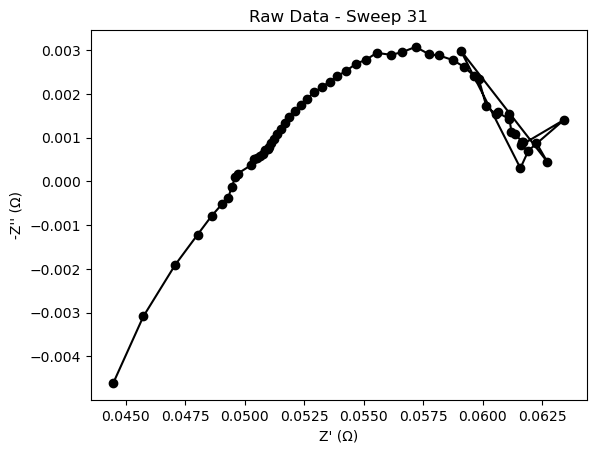

Fitting failed: too many values to unpack (expected 2)


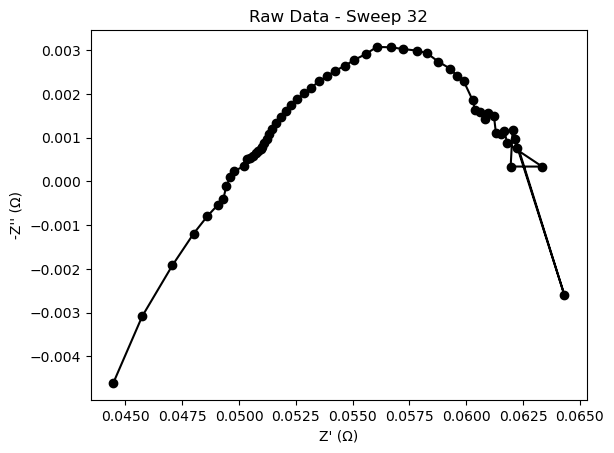

Fitting failed: too many values to unpack (expected 2)


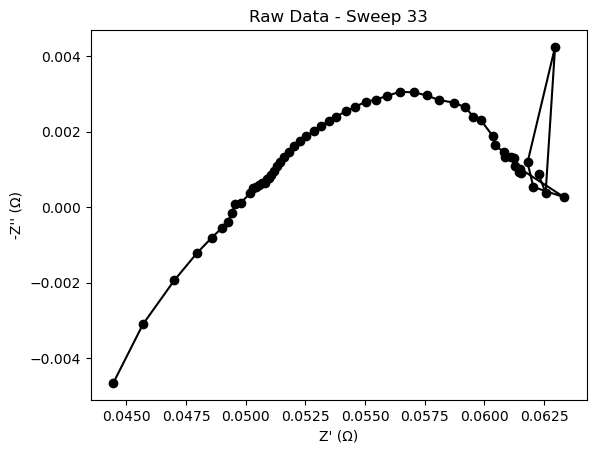

Fitting failed: too many values to unpack (expected 2)


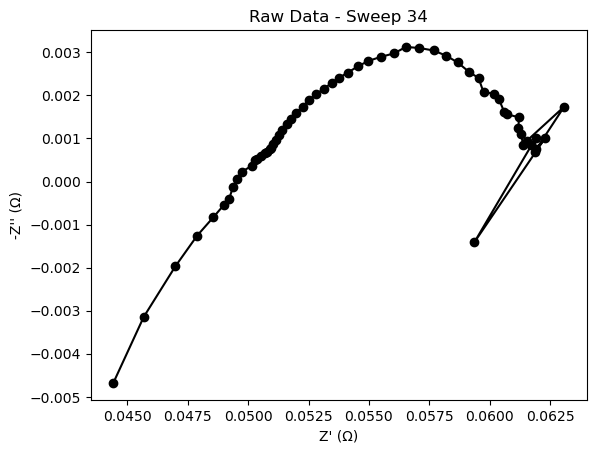

Fitting failed: too many values to unpack (expected 2)


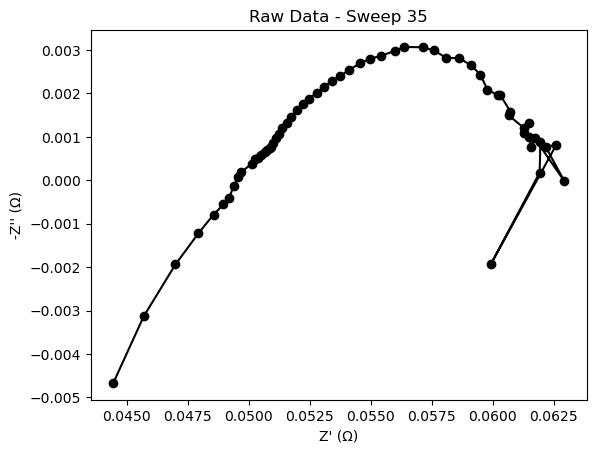

Fitting failed: too many values to unpack (expected 2)


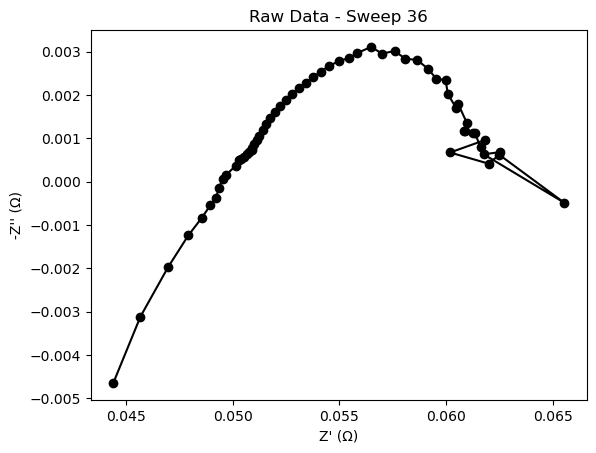

Fitting failed: too many values to unpack (expected 2)


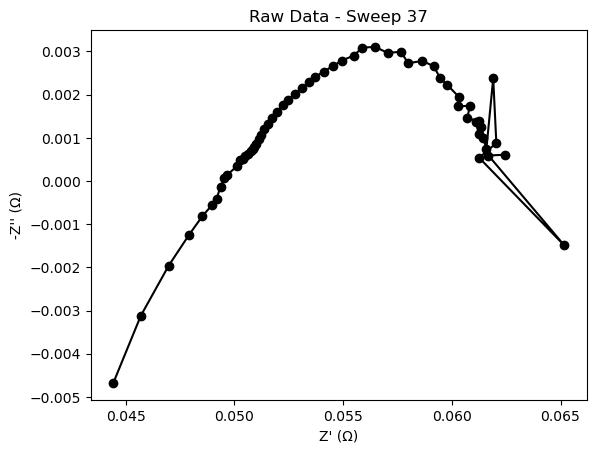

Fitting failed: too many values to unpack (expected 2)


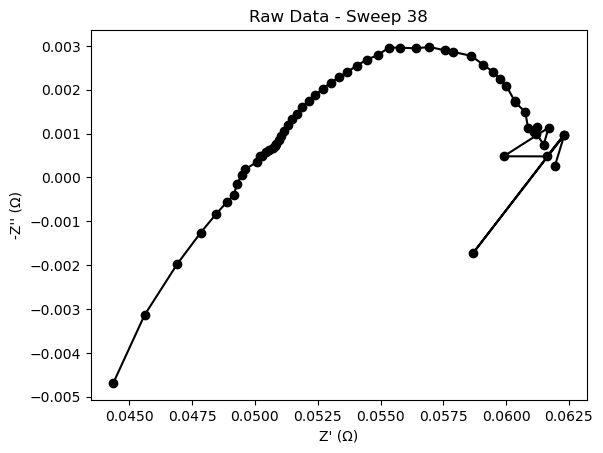

Fitting failed: too many values to unpack (expected 2)


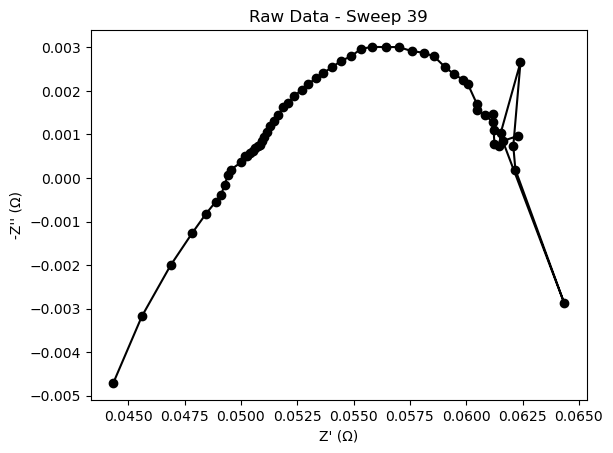

Fitting failed: too many values to unpack (expected 2)


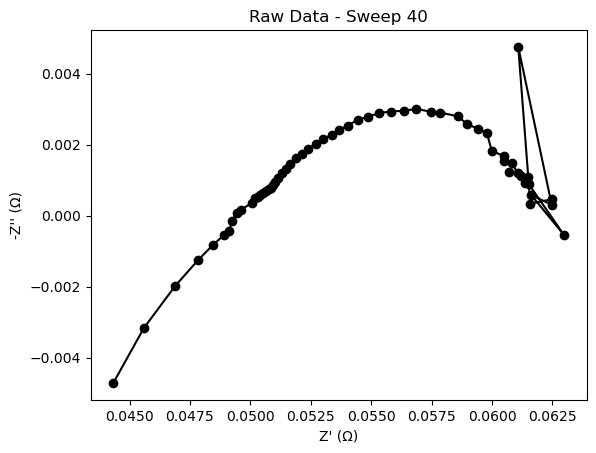

Fitting failed: too many values to unpack (expected 2)


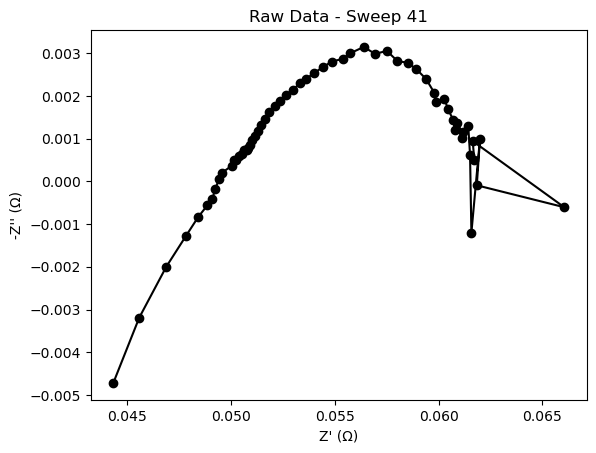

Fitting failed: too many values to unpack (expected 2)


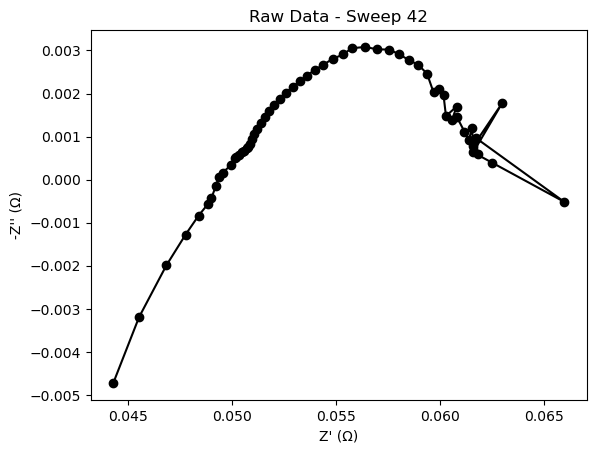

Fitting failed: too many values to unpack (expected 2)


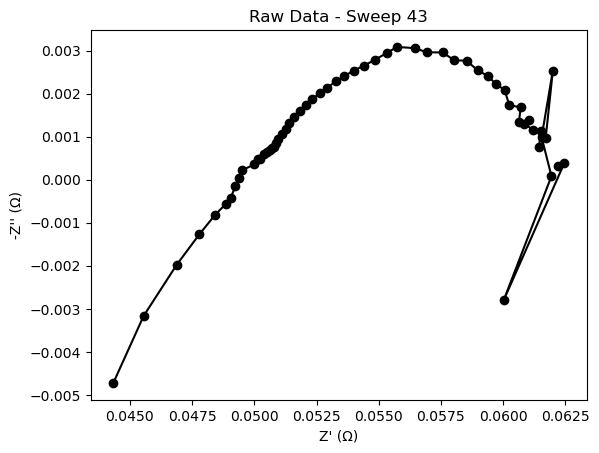

Fitting failed: too many values to unpack (expected 2)


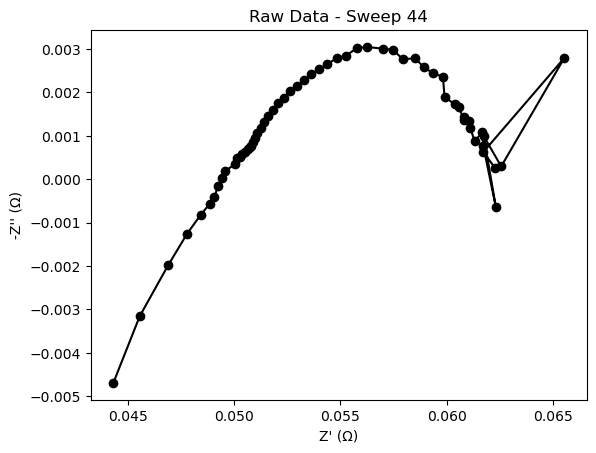

Fitting failed: too many values to unpack (expected 2)


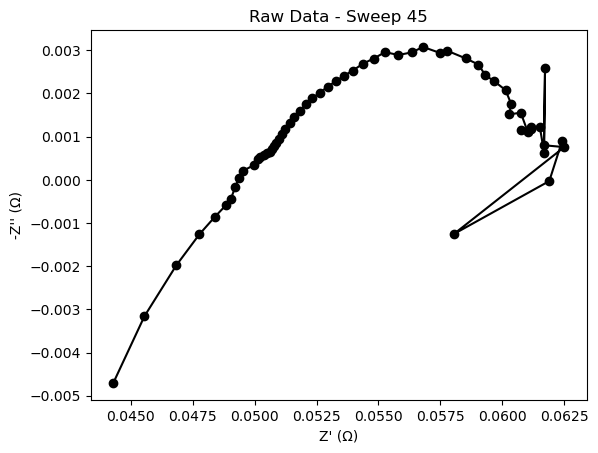

Fitting failed: too many values to unpack (expected 2)


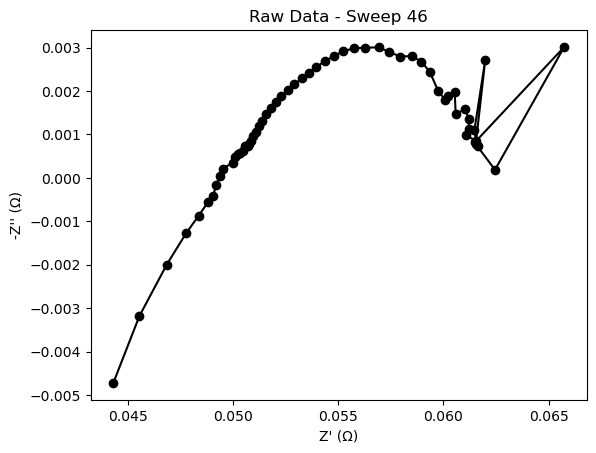

Fitting failed: too many values to unpack (expected 2)


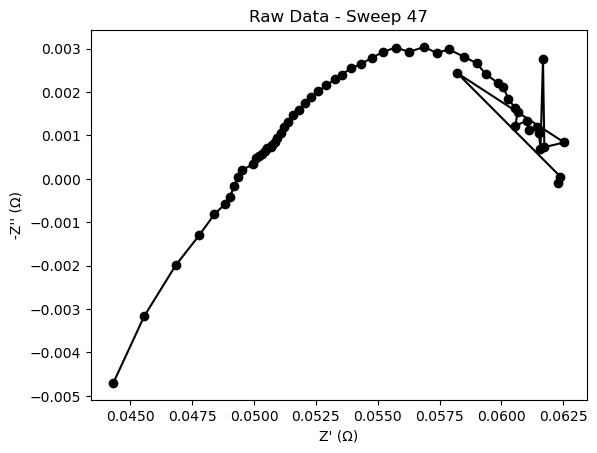

Fitting failed: too many values to unpack (expected 2)


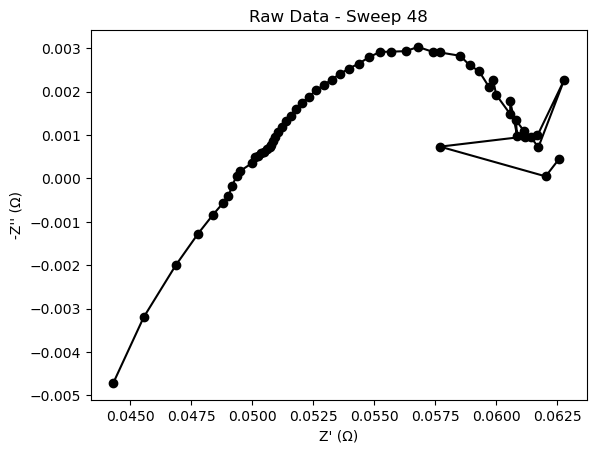

Fitting failed: too many values to unpack (expected 2)


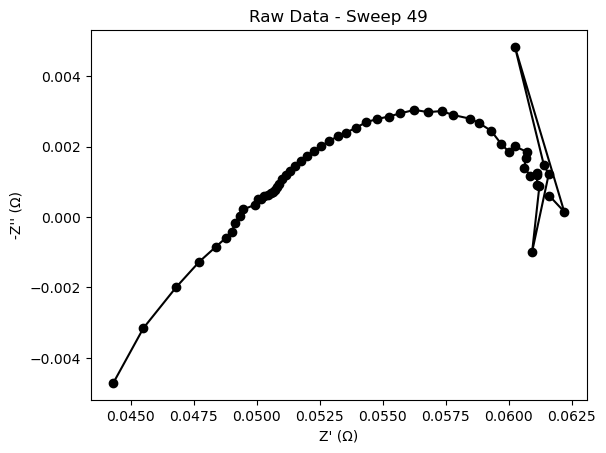

Fitting failed: too many values to unpack (expected 2)


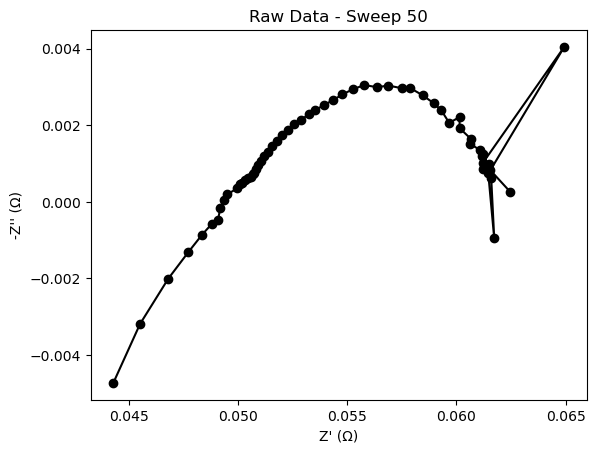

Fitting failed: too many values to unpack (expected 2)


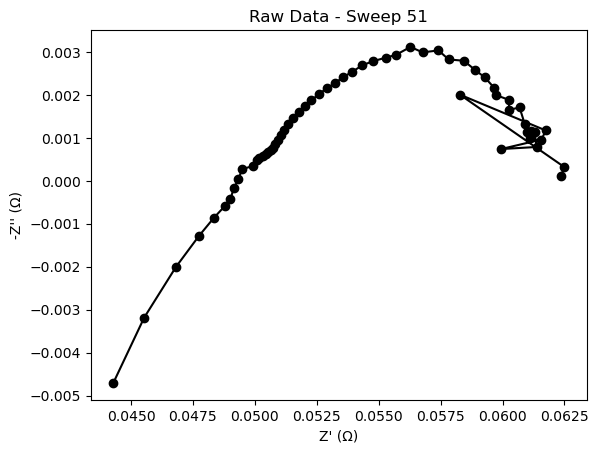

Fitting failed: too many values to unpack (expected 2)


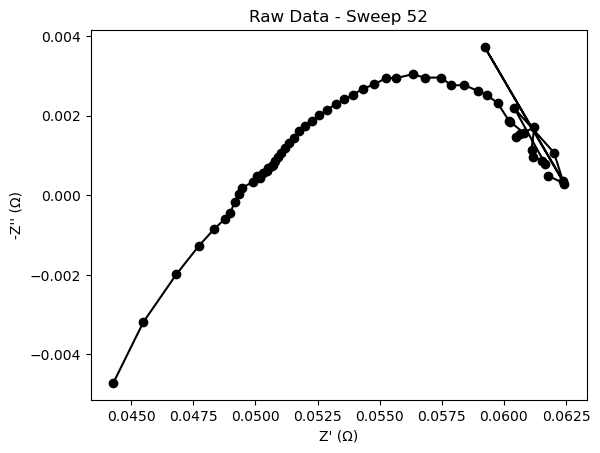

Fitting failed: too many values to unpack (expected 2)


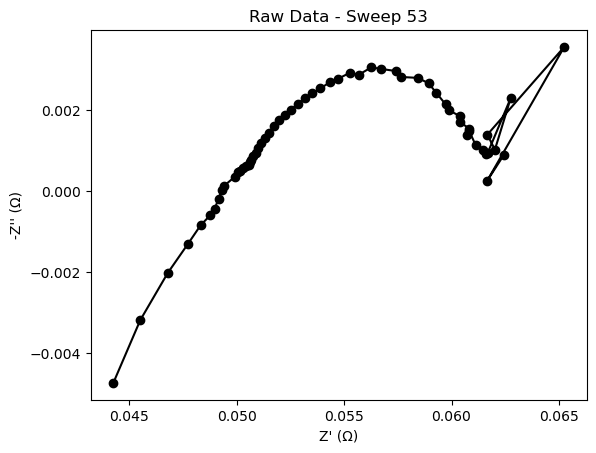

Fitting failed: too many values to unpack (expected 2)


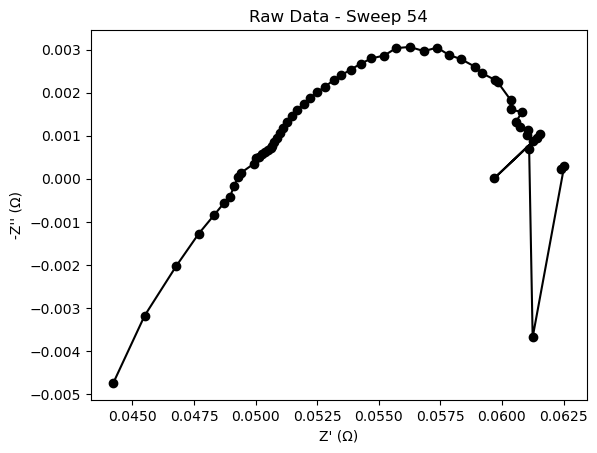

Fitting failed: too many values to unpack (expected 2)


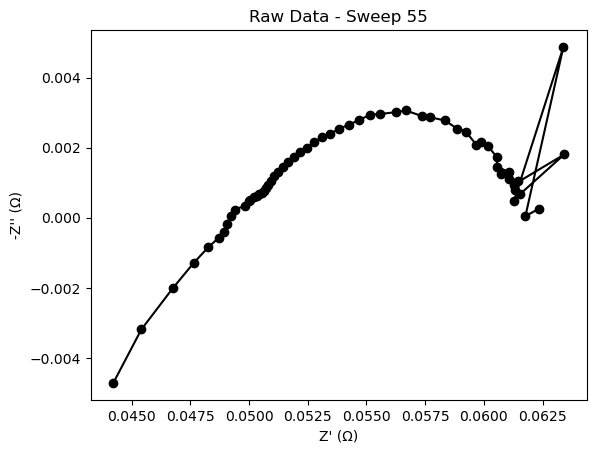

Fitting failed: too many values to unpack (expected 2)


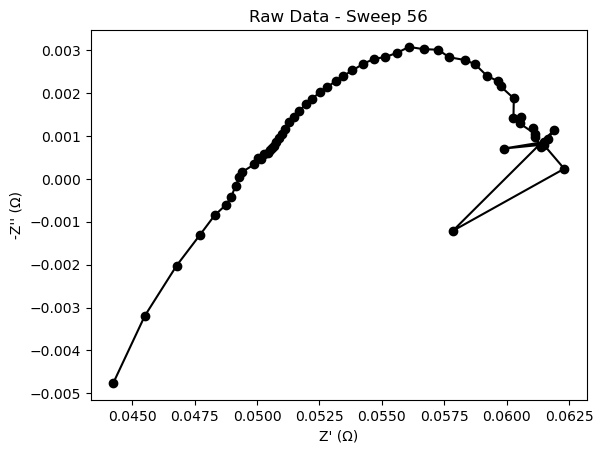

Fitting failed: too many values to unpack (expected 2)


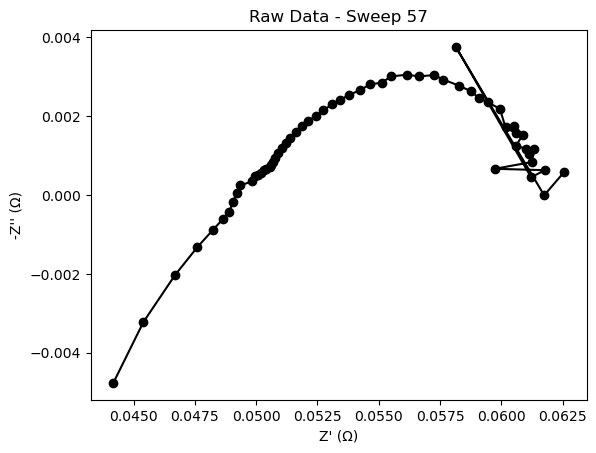

Fitting failed: too many values to unpack (expected 2)


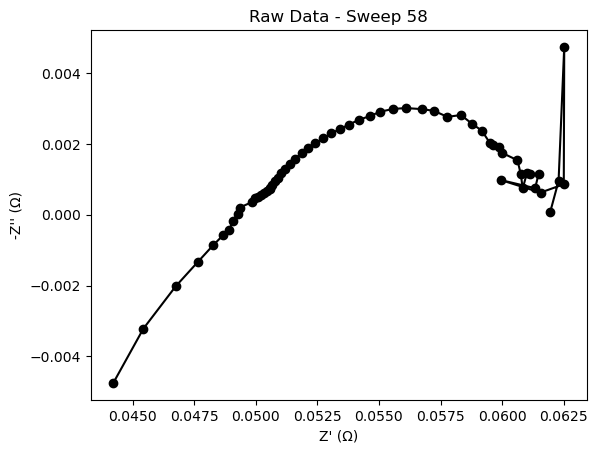

Fitting failed: too many values to unpack (expected 2)


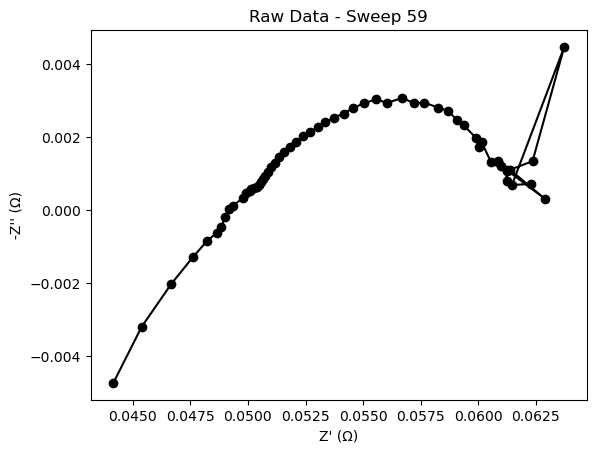

Fitting failed: too many values to unpack (expected 2)


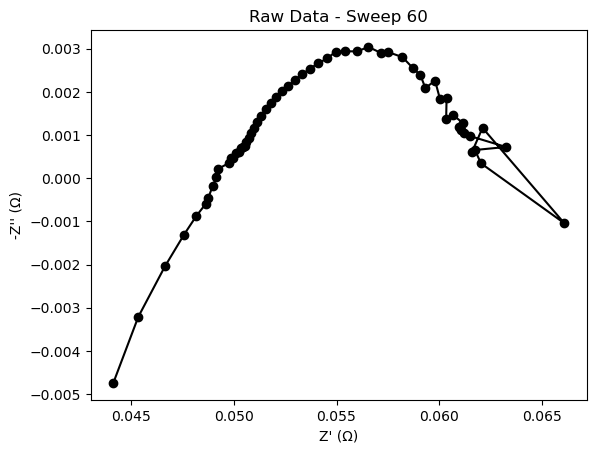

Fitting failed: too many values to unpack (expected 2)


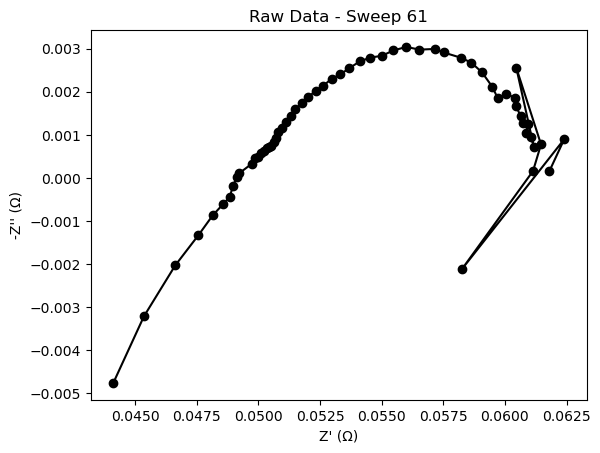

Fitting failed: too many values to unpack (expected 2)


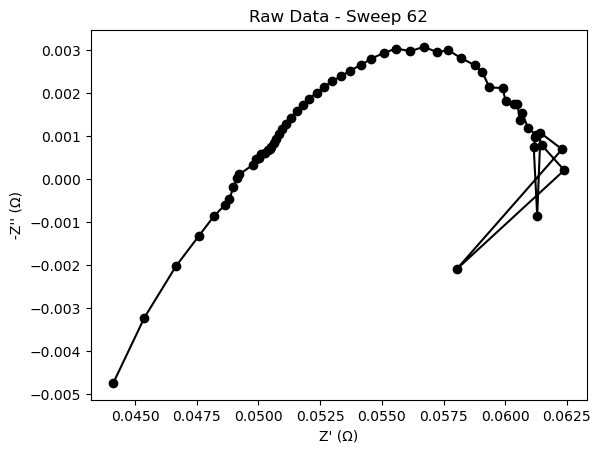

Fitting failed: too many values to unpack (expected 2)


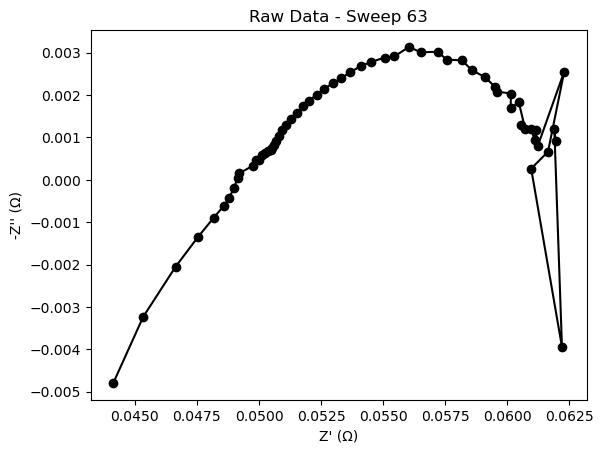

Fitting failed: too many values to unpack (expected 2)


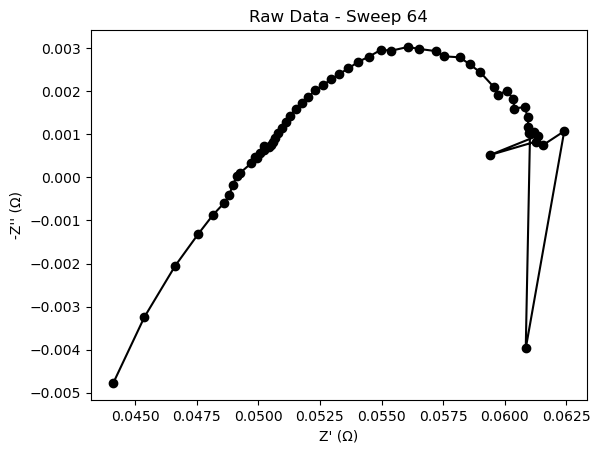

Fitting failed: too many values to unpack (expected 2)


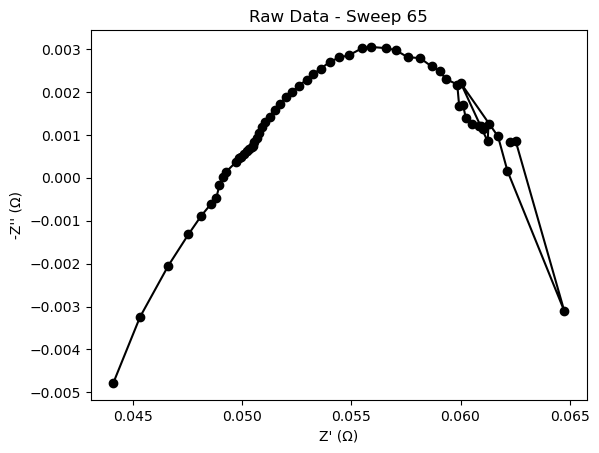

Fitting failed: too many values to unpack (expected 2)


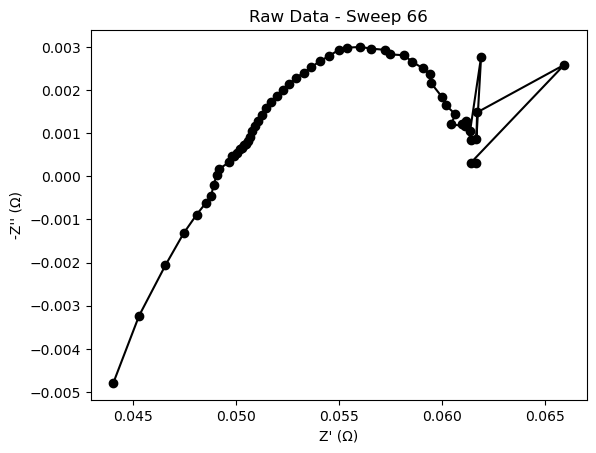

Fitting failed: too many values to unpack (expected 2)


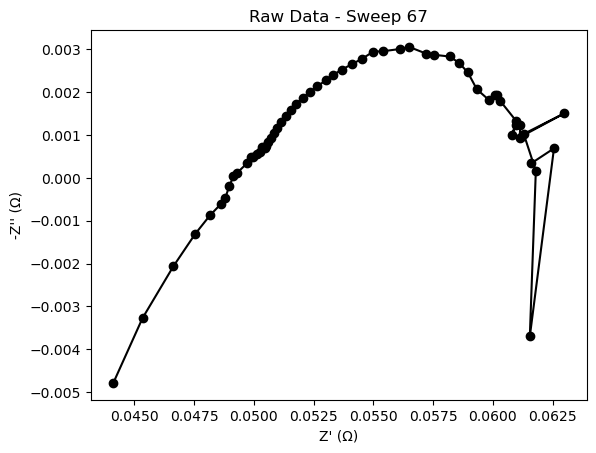

Fitting failed: too many values to unpack (expected 2)


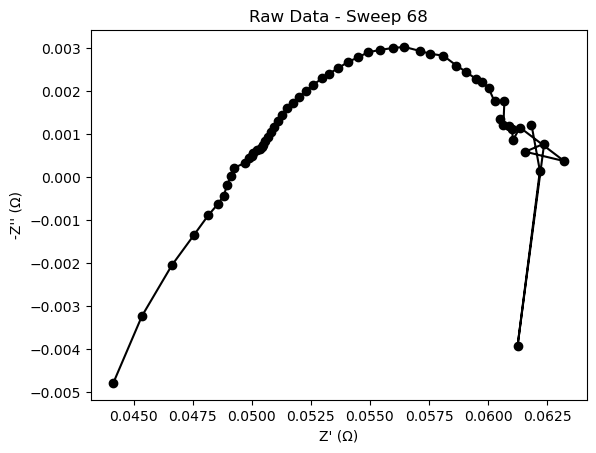

Fitting failed: too many values to unpack (expected 2)


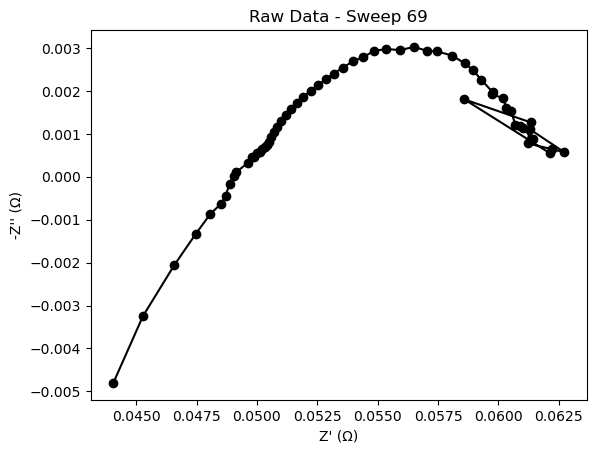

Fitting failed: too many values to unpack (expected 2)


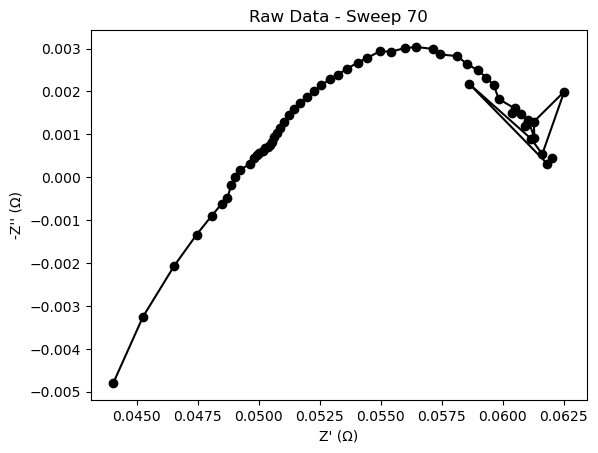

Fitting failed: too many values to unpack (expected 2)


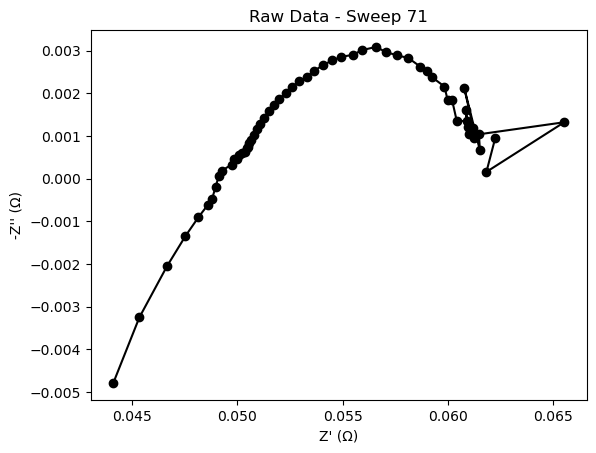

Fitting failed: too many values to unpack (expected 2)


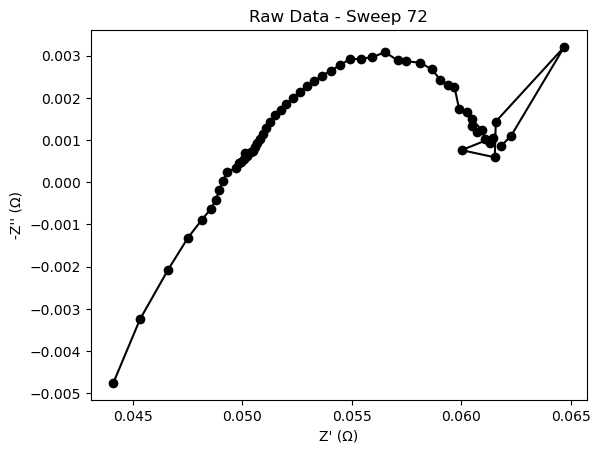

Fitting failed: too many values to unpack (expected 2)


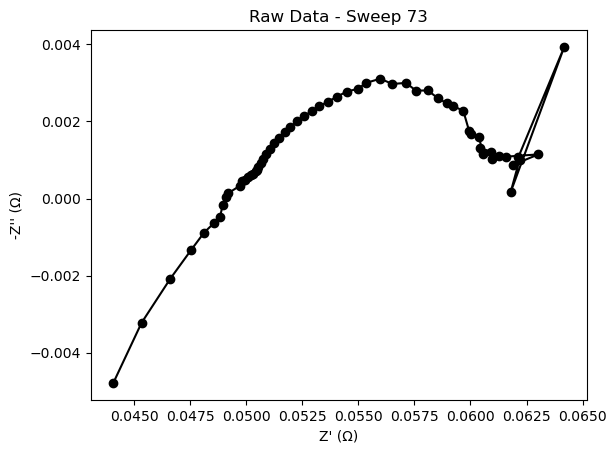

Fitting failed: too many values to unpack (expected 2)


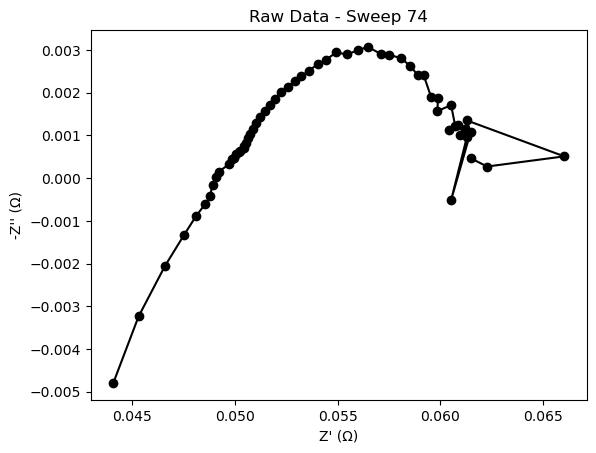

Fitting failed: too many values to unpack (expected 2)

FAILURE ANALYSIS:
1. Check raw data plots for anomalies
2. Verify frequency values are positive
3. Confirm impedance values are finite
4. Try relaxing parameter bounds


In [55]:
# 1. DATA LOADING (keep your original version)
# ... [your original data loading code] ...

# 2. ECM MODEL (simplified for reliability)
working_model = {
    "name": "Reliable_RC",
    "circuit": "R0-p(R1-CPE1)",
    "initial_guess": [0.05, 0.01, 1e-5, 0.8],  # R0, R1, CPE1-Q, CPE1-alpha
    "bounds": [
        (0, 0.1),    # R0
        (0, 0.1),    # R1
        (1e-6, 1e-3),  # CPE1-Q
        (0.5, 1)     # CPE1-alpha
    ],
    "param_names": ["R0", "R1", "CPE1-Q", "CPE1-alpha"]
}

# 3. DIAGNOSTIC FITTING FUNCTION
def robust_fit(model_dict, freq, Z_exp):
    """Enhanced fitting with detailed error reporting"""
    try:
        # Initialize circuit
        circuit = CustomCircuit(
            circuit=model_dict["circuit"],
            initial_guess=model_dict["initial_guess"]
        )
        
        # Perform fit
        circuit.fit(freq, Z_exp, bounds=model_dict["bounds"])
        
        # Validate results
        params = circuit.parameters_
        print(f"Fitted parameters: {dict(zip(model_dict['param_names'], params))}")
        
        # Generate prediction
        Z_fit = circuit.predict(freq)
        rmse = np.sqrt(np.mean(np.abs(Z_exp - Z_fit)**2))
        print(f"RMSE: {rmse:.2e}")
        
        return {
            "params": params,
            "rmse": rmse,
            "Z_fit": Z_fit
        }
        
    except Exception as e:
        print(f"Fitting failed: {str(e)}")
        return None

# 4. DATA VALIDATION AND FITTING
fit_results = []
for sweep_id, group in df_eis.groupby("sweep_id"):
    group = group.sort_values("frequency")
    if len(group) < 5:  # Minimum 5 points per sweep
        print(f"Skipping sweep {sweep_id} - insufficient points")
        continue
        
    freq = group["frequency"].values
    Z_exp = group["Z_real"].values + 1j*(-group["Z_imag_neg"].values)
    
    # Plot raw data for inspection
    plt.figure()
    plt.plot(Z_exp.real, -Z_exp.imag, 'ko-')
    plt.title(f"Raw Data - Sweep {sweep_id}")
    plt.xlabel("Z' (Ω)"); plt.ylabel("-Z'' (Ω)")
    plt.show()
    
    # Perform fit
    result = robust_fit(working_model, freq, Z_exp)
    if result:
        result.update({"sweep_id": sweep_id})
        fit_results.append(result)

if not fit_results:
    print("\nFAILURE ANALYSIS:")
    print("1. Check raw data plots for anomalies")
    print("2. Verify frequency values are positive")
    print("3. Confirm impedance values are finite")
    print("4. Try relaxing parameter bounds")
else:
    fit_df = pd.DataFrame(fit_results)
    
    # Plot first successful fit
    first_row = fit_df.iloc[0]
    plot_nyquist(
        first_row['sweep_id'],
        first_row['Z_fit'],
        first_row['rmse']
    )